# 23 - Specialist reference: compare sales proxies on retained evidence

Read **coverage → retained examples → method comparison → estimates/revisions →
exit validation → next checks**. Older holdouts, sampling audits and vendor research
follow as optional sections. [Notebook 20](20_carvana_history_analysis.ipynb) explains
inventory changes and prices; [Notebook 22](22_carvana_sale_status_validation.ipynb)
explains frozen membership and native transitions.

At the reference cutoff, the frozen **33 VINs (30 prospective, 3 historical controls)**
contain one qualifying first native `Available → Sold` transition. Ten separately
selected inventory exits later have native Sold labels. These are different
observations; neither proves a completed transaction. The central proxy assigns one
assumed event unit to the frozen-cohort transition, without a national multiplier.

**Run All is offline and read-only.** Source paths and timestamps remain in the tables.
Estimated units, native website statuses, inventory observations and independently
confirmed transactions stay separate. Independent transaction outcomes are unavailable.

This is a historical study replay at the selected cutoff, using the original
33-VIN cohort and original Tesla inventory history. It is not the daily operating
instruction for the broader 101-query panel. Use **20 -> 24** for routine review,
and the [current seven-date plan](../data/experiments/mvp_completion_20260912/scale_acceptance_20260912/proposed_seven_date_validation.md)
for the separately prepared operating validation. Older proposals below remain historical.


In [1]:
import sys, json, hashlib
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'vehicle/src/vehicle_tracker').is_dir()) / 'vehicle'
sys.path.insert(0, str(ROOT / 'src'))
from vehicle_tracker.daily import tracking_settings, tracking_history, daily_tables
from vehicle_tracker.sale_pilot import select_extension
from vehicle_tracker.history import read_query_evidence
from vehicle_tracker.research_inputs import load_detail_evidence
from vehicle_tracker.sales_proxy import (native_visits, native_transition_events, inventory_flows,
    disappearance_events, cohort_estimates, allocate_intervals,
    reappearance_summary, inventory_followup_queue, native_estimate_revisions, inventory_exit_episodes)



## Settings and retained inputs

Run the cells in order. The fixed reference cutoff makes this review reproducible.
Change `AS_OF` to replay earlier evidence, `EXAMPLE_VINS`/`EXIT_EXAMPLE_VIN` to trace
other retained vehicles, or the preview's seed/counts to inspect a different sample.
Use a timezone-aware cutoff; keep the visit cap at 12 or below. These settings only
read local files and prepare a preview.

The two frozen cohort files define membership. The diagnostic plan/pass files
below describe separate visits; they cannot add vehicles to that cohort.

The shared evidence reader includes later saved browser and diagnostic checks for an existing frozen VIN in its current event estimate. Membership remains the original 33 VINs; new validation vehicles stay outside the cohort. Earlier cutoffs exclude later-available evidence, and the revision table preserves the original event contribution.

Edit the ordinary settings cell below. Advanced overrides and fixed source paths
are separated in the following setup cell; the two cohort files remain frozen.
`calendar` describes observed/missing dates, `output_table` / `scenario_totals` compare scoped assumptions,
and revision/allocation tables expose event timing and later evidence. Unavailable
absence estimates mean insufficient complete follow-up, not zero sales. The source
paths, actual inventory-date range and evidence cutoff are printed after loading.


In [2]:
# Ordinary settings for this historical specialist review.
AS_OF = '2026-09-12T11:37:13.019826+00:00'
EXAMPLE_VINS = ['5YJ3E1EA7NF288274', '5YJ3E1EA2PF544050', '5YJ3E1EA0PF668477', '5YJ3E1EAXPF590130']
EXIT_EXAMPLE_VIN = '5YJ3E1EA0MF058297'
BATCH_LIMIT = 12  # Offline queue preview only.
CONTROL_COUNT = 2
SELECTION_SEED = 'carvana-vendor-review-20260911'


### Advanced overrides and fixed reference sources

Automated exports may supply `*_OVERRIDE` values. Ordinary review needs only the
cell above. These paths retain the original study population; select broader-panel
operating history in Notebook 20 and an explicit frozen study in Notebook 24.


In [3]:
AS_OF = globals().get('AS_OF_OVERRIDE', AS_OF)
BATCH_LIMIT = globals().get('BATCH_LIMIT_OVERRIDE', BATCH_LIMIT)
CONTROL_COUNT = globals().get('CONTROL_COUNT_OVERRIDE', CONTROL_COUNT)
SELECTION_SEED = globals().get('SELECTION_SEED_OVERRIDE', SELECTION_SEED)
TZ = 'America/New_York'
REVIEW = ROOT / 'data/experiments/vendor_review/20260911T162600Z'
SETTINGS = tracking_settings(ROOT / 'config/carvana_daily_tracking.json')
COHORT_FILES = [ROOT / 'config/carvana_sale_pilot.json', ROOT / 'config/carvana_sale_pilot_extension_20260909.json']
print('Reference inventory configuration:', SETTINGS['config_path'])
print('Reference inventory database:', SETTINGS['database'])
print('Frozen cohort files:', *COHORT_FILES, sep='\n')


Reference inventory configuration: C:\Users\Sean\VscProjects\researchOS\vehicle\config\carvana_daily_tracking.json
Reference inventory database: C:\Users\Sean\VscProjects\researchOS\vehicle\data\analysis\carvana_daily\history.sqlite
Frozen cohort files:
c:\Users\Sean\VscProjects\researchOS\vehicle\config\carvana_sale_pilot.json
c:\Users\Sean\VscProjects\researchOS\vehicle\config\carvana_sale_pilot_extension_20260909.json


In [4]:
evidence = load_detail_evidence(ROOT, AS_OF)
cohorts = evidence['cohorts']
days, inventory = tracking_history(SETTINGS, as_of=AS_OF)
# Membership stays frozen; every known matched observation can update that VIN.
records = evidence['records']
RESEARCH_READY = bool(cohorts)
all_visits = native_visits(records, as_of=AS_OF)
cohort_keys = {(v['retailer'], v['vin']) for cohort in cohorts for v in cohort['vehicles']}
# Descriptive cohort history/counts exclude separately selected validation vehicles.
visits = all_visits.loc[[tuple(key) in cohort_keys for key in
    all_visits[['retailer', 'vin']].itertuples(index=False, name=None)]].copy() if not all_visits.empty else all_visits
native_events, panel = native_transition_events(records, cohorts, as_of=AS_OF, cycles=days, observations=inventory)
tracking = daily_tables(days, inventory, as_of=AS_OF, timezone_name=TZ)
calendar = tracking['daily_inventory']
input_paths = set(evidence['input_paths']) | set(COHORT_FILES + [SETTINGS['config_path'], SETTINGS['plan'], SETTINGS['register'], SETTINGS['database']])
input_paths.update(Path(p) for p in inventory.source_path)
for entry in json.loads(SETTINGS['register'].read_text())['cycles']:
    input_paths.add(Path(entry['path']))
    input_paths.update(Path(p) for p in entry['reports'])
print('Evidence cutoff:', AS_OF, '| clocks displayed in UTC unless a local date is labeled')
print('Cohort membership is frozen; later known checks update its existing VINs without adding validation vehicles.')
print('No independent transaction labels; transaction precision and recall are not estimable.')
research_tables = {'coverage': calendar}
if not RESEARCH_READY:
    print('NO KNOWN COHORT at this cutoff. Inventory coverage is shown; event estimates are unavailable.')
    display(calendar)

# Shared loader reads each plan/pass once and preserves its separate selection.
first_pass = evidence['research_passes']['pass.json']
exit_pass = evidence['research_passes']['exit_batch_pass.json']
pass_plan, review_pass, pass_observations = first_pass['selected'], first_pass['report'], first_pass['records']
exit_plan, exit_report, exit_validation = exit_pass['selected'], exit_pass['report'], exit_pass['records'].copy()
REVIEW_AVAILABLE = review_pass is not None
browser_records, browser_health = evidence['browser_records'], evidence['browser_health']
selection_plans = evidence['selection_plans']
queue_records = records  # The same cutoff-safe evidence, without a second concatenation.

if not days.empty:
    print('Selected inventory dates:', days.cycle_date.min(), 'through', days.cycle_date.max())
print('Review mode: historical study replay at the displayed fixed cutoff.')


Evidence cutoff: 2026-09-12T11:37:13.019826+00:00 | clocks displayed in UTC unless a local date is labeled
Cohort membership is frozen; later known checks update its existing VINs without adding validation vehicles.
No independent transaction labels; transaction precision and recall are not estimable.
Selected inventory dates: 2026-09-08 through 2026-09-11
Review mode: historical study replay at the displayed fixed cutoff.


## Retained inputs and coverage

`inventory_count` is unique retailer/VINs after all seven fixed queries pass retention, pagination, identity and SQLite reconciliation. Missing dates remain missing. Native pending and asking price describe listings. Different sweep times mean even adjacent local dates need not span 24 hours.


,cycle_date,coverage_status,inventory_count,pending_true,pending_unknown,average_asking_price_usd,missing_prices
0,2026-09-08,complete,674,215,0,28219.376855,0
1,2026-09-09,complete,681,205,0,28292.202643,0
2,2026-09-10,missing,<NA>,<NA>,<NA>,NaN,<NA>
3,2026-09-11,complete,706,227,0,28371.303116,0
4,2026-09-12,missing,<NA>,<NA>,<NA>,NaN,<NA>


,cycle_date,window_start,window_end,available_at,scope_id,coverage_reason
0,2026-09-08,2026-09-09T01:44:11.074146+00:00,2026-09-09T01:45:40.704618+00:00,2026-09-09T01:45:40.724750+00:00,4a8ee109d5ada141f87906d073c725319b96c248fbcad1...,Complete requested daily scope
1,2026-09-09,2026-09-09T10:59:31.570451+00:00,2026-09-09T11:01:07.356095+00:00,2026-09-09T11:01:07.378901+00:00,4a8ee109d5ada141f87906d073c725319b96c248fbcad1...,Complete requested daily scope
2,2026-09-11,2026-09-11T10:53:30.283953+00:00,2026-09-11T10:55:10.719183+00:00,2026-09-11T10:55:10.763717+00:00,4a8ee109d5ada141f87906d073c725319b96c248fbcad1...,Complete requested daily scope


,selected_vins,prospective_vins,physical_checks,matched_native_checks,access_failed_checks,initially_sold_vins,historical_controls,qualifying_first_sold,independently_supported_transactions
0,33,30,84,83,1,3,3,1,<NA>


,role,latest_status,VINs
0,historical_control,sold_label,2
1,historical_control,unavailable,1
2,prospective_inventory,available,4
3,prospective_inventory,pending,16
4,prospective_inventory,sold_label,2
5,prospective_inventory,unavailable,1
6,prospective_inventory,unknown,7


,date,explicit_inventory_requests,sweep_seconds,complete_queries,requested_queries,response_content_bytes
0,2026-09-08,31,89.630472,7,7,5981659
1,2026-09-09,33,95.785644,7,7,6145560
2,2026-09-11,35,100.435230,7,7,6586088


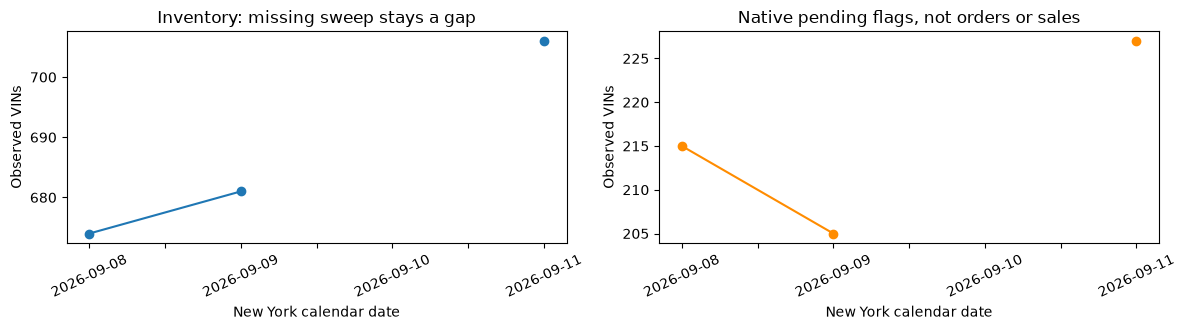

In [5]:
if RESEARCH_READY:
    display(calendar[['cycle_date', 'coverage_status', 'inventory_count', 'pending_true', 'pending_unknown',
                      'average_asking_price_usd', 'missing_prices']])
    display(days[['cycle_date', 'window_start', 'window_end', 'available_at', 'scope_id', 'coverage_reason']])
    coverage_counts = pd.DataFrame([dict(selected_vins=len(panel), prospective_vins=int(panel.role.eq('prospective_inventory').sum()),
        physical_checks=len(visits), matched_native_checks=int((visits.parse_outcome.eq('matched') & visits.saleStatus.isin(['Available', 'Sold'])).sum()),
        access_failed_checks=int(visits.parse_outcome.eq('access_failed').sum()),
        initially_sold_vins=int(panel.first_encountered_sold.sum()), historical_controls=int(panel.role.eq('historical_control').sum()),
        qualifying_first_sold=int(panel.newly_observed_sold.sum()), independently_supported_transactions=pd.NA)])
    display(coverage_counts)
    latest_status_counts = panel.groupby(['role', 'latest_status'], dropna=False).size().rename('VINs').reset_index()
    display(latest_status_counts)
    collection_costs = []
    for day in days.itertuples():
        cycle_path = next(Path(e['path']) for e in json.loads(SETTINGS['register'].read_text())['cycles'] if e['cycle_id'] == day.cycle_id)
        state = json.loads(cycle_path.read_text())
        reports = [json.loads(p.read_text()) for p in cycle_path.parent.glob('attempt_*/*/run_report.json')]
        collection_costs.append(dict(date=day.cycle_date, explicit_inventory_requests=sum(r['requests'] for r in reports),
            sweep_seconds=(pd.Timestamp(day.window_end) - pd.Timestamp(day.window_start)).total_seconds(),
            complete_queries=sum(r['query_complete'] for r in reports), requested_queries=len(state['queries']),
            response_content_bytes=sum(page.get('response_bytes', 0) for r in reports for page in r['pages'])))
    collection_costs = pd.DataFrame(collection_costs)
    display(collection_costs)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
    calendar.set_index('cycle_date').inventory_count.astype('Float64').astype(float).plot(ax=axes[0], marker='o', title='Inventory: missing sweep stays a gap')
    calendar.set_index('cycle_date').pending_true.astype('Float64').astype(float).plot(ax=axes[1], marker='o', color='darkorange', title='Native pending flags, not orders or sales')
    for ax in axes: ax.set_xlabel('New York calendar date'); ax.set_ylabel('Observed VINs'); ax.tick_params(axis='x', rotation=25)
    plt.tight_layout(); plt.show()


## Individual vehicles, from source to calculation

The examples are the first-Sold transition, an initially Sold vehicle, a pending-to-available vehicle, and the earliest daily disappearance. Each record keeps listing ID, VIN, physical observation time, local evidence availability and source. An unavailable/pre-order page is not automatically Sold. A later Available label does not prove a cancellation or return.
The native history shown here is restricted to frozen-cohort VINs. Browser/pass tables below separately show their complete selected samples; those additional vehicles are not pooled into the cohort denominator.


In [6]:
if RESEARCH_READY:
    status_history = visits.loc[visits.vin.isin(EXAMPLE_VINS), ['retailer', 'vin', 'listing_id', 'checked_at', 'available_at',
        'saleStatus', 'purchaseType', 'inventoryType', 'observed_status', 'parse_outcome', 'source']].sort_values(['vin', 'checked_at'])
    inventory_history = inventory.loc[inventory.vin.isin(EXAMPLE_VINS)].merge(days[['cycle_id', 'cycle_date', 'available_at']], on='cycle_id')
    display(status_history)
    display(inventory_history[['vin', 'listing_id', 'cycle_date', 'observed_at_utc', 'available_at', 'purchase_pending',
        'asking_price_usd', 'inventory_type', 'capture_id', 'source_path']].sort_values(['vin', 'observed_at_utc']))
    # Trace one retained projection into the SQLite row read by tracking_history.
    trace_records = []
    for vin in [EXAMPLE_VINS[0], EXAMPLE_VINS[-1]]:
        matching = inventory_history.loc[inventory_history.vin.eq(vin)]
        if matching.empty: continue
        trace = matching.iloc[-1]
        raw_path = Path(trace.source_path)
        raw_vehicle = next(v for v in json.loads(raw_path.read_text())['vehicles'] if str(v['vehicleId']) == trace.listing_id)
        trace_records.extend([dict(layer='retained JSON', vin=raw_vehicle['vin'], listing_id=str(raw_vehicle['vehicleId']),
             asking_price_usd=raw_vehicle['price']['total'], pending=raw_vehicle['isPurchasePending'], source=str(raw_path)),
        dict(layer='SQLite / notebook', vin=trace.vin, listing_id=trace.listing_id,
             asking_price_usd=trace.asking_price_usd, pending=trace.purchase_pending, source=str(SETTINGS['database']))])
    trace_table = pd.DataFrame(trace_records)
    display(trace_table)
    for _, trace_pair in trace_table.groupby('vin'):
        assert trace_pair.listing_id.nunique() == trace_pair.asking_price_usd.nunique() == trace_pair.pending.nunique() == 1


,retailer,vin,listing_id,checked_at,available_at,saleStatus,purchaseType,inventoryType,observed_status,parse_outcome,source
29,carvana,5YJ3E1EA0PF668477,4722528,2026-09-10 00:25:48.087000+00:00,2026-09-10 01:37:44.007874+00:00,Available,Purchasable,Core,available,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
56,carvana,5YJ3E1EA0PF668477,4722528,2026-09-10 04:10:41.306000+00:00,2026-09-10 04:12:05.852662+00:00,Available,Purchasable,Core,available,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
88,carvana,5YJ3E1EA0PF668477,4722528,2026-09-11 16:29:09.338000+00:00,2026-09-11 16:35:30.190162+00:00,Available,Purchasable,Core,available,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
32,carvana,5YJ3E1EA2PF544050,4674263,2026-09-10 00:25:59.445000+00:00,2026-09-10 01:37:44.007874+00:00,Sold,NotPurchasable,Core,sold_label,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
86,carvana,5YJ3E1EA2PF544050,4674263,2026-09-11 16:28:11.223000+00:00,2026-09-11 16:35:30.190162+00:00,Sold,NotPurchasable,Core,sold_label,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
37,carvana,5YJ3E1EA7NF288274,4567173,2026-09-10 00:26:18.172000+00:00,2026-09-10 01:37:44.007874+00:00,Available,Purchasable,Core,pending,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
62,carvana,5YJ3E1EA7NF288274,4567173,2026-09-11 02:19:09.912000+00:00,2026-09-11 02:23:02.872973+00:00,Sold,NotPurchasable,Core,sold_label,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
0,carvana,5YJ3E1EAXPF590130,4632932,2026-09-09 11:18:44.243000+00:00,2026-09-09 11:24:34+00:00,Available,NotPurchasable,Core,unavailable,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
8,carvana,5YJ3E1EAXPF590130,4632932,2026-09-09 11:43:05.612000+00:00,2026-09-09 11:47:36.697004+00:00,Available,NotPurchasable,Core,unavailable,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
14,carvana,5YJ3E1EAXPF590130,4632932,2026-09-10 00:24:24.120000+00:00,2026-09-10 01:37:43.083387+00:00,Available,NotPurchasable,Core,unavailable,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...


,vin,listing_id,cycle_date,observed_at_utc,available_at,purchase_pending,asking_price_usd,inventory_type,capture_id,source_path
1,5YJ3E1EA0PF668477,4722528,2026-09-08,2026-09-09T01:44:31.838643+00:00,2026-09-09T01:45:40.724750+00:00,1,28990.0,1,c04d43222f567085a0830e5bdad8a709af54f1ba4938fc...,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
5,5YJ3E1EA0PF668477,4722528,2026-09-09,2026-09-09T10:59:52.501065+00:00,2026-09-09T11:01:07.378901+00:00,1,28990.0,1,8c1eb0629fd1b8a8758ba4006c6ec30139a6764a761dcc...,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
2,5YJ3E1EA2PF544050,4674263,2026-09-08,2026-09-09T01:44:37.951868+00:00,2026-09-09T01:45:40.724750+00:00,1,27990.0,1,1de0356c5e5a5c24261157899fe56bcb72765564db6ba2...,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
6,5YJ3E1EA2PF544050,4674263,2026-09-09,2026-09-09T10:59:58.335963+00:00,2026-09-09T11:01:07.378901+00:00,1,27990.0,1,b2dece999ac769d38b97b3998c160fef303b4ee1d36607...,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
3,5YJ3E1EA7NF288274,4567173,2026-09-08,2026-09-09T01:44:52.925909+00:00,2026-09-09T01:45:40.724750+00:00,1,24990.0,1,f9c4df8e9223d91ab910ec9c291046420b60851c275c42...,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
4,5YJ3E1EA7NF288274,4567173,2026-09-09,2026-09-09T11:00:13.406079+00:00,2026-09-09T11:01:07.378901+00:00,1,24990.0,1,5c6edb953bcc729a508147b220d492977f51859d19f585...,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
0,5YJ3E1EAXPF590130,4632932,2026-09-08,2026-09-09T01:44:16.996205+00:00,2026-09-09T01:45:40.724750+00:00,0,26590.0,1,1f8d9e17af356a5cd55a7d8bf9f357be04b4ce67b23faf...,C:\Users\Sean\VscProjects\researchOS\vehicle\d...


,layer,vin,listing_id,asking_price_usd,pending,source
0,retained JSON,5YJ3E1EA7NF288274,4567173,24990.0,True,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
1,SQLite / notebook,5YJ3E1EA7NF288274,4567173,24990.0,1,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
2,retained JSON,5YJ3E1EAXPF590130,4632932,26590.0,False,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
3,SQLite / notebook,5YJ3E1EAXPF590130,4632932,26590.0,0,C:\Users\Sean\VscProjects\researchOS\vehicle\d...


## Alternative methods and their assumptions

1. **Native transition:** one event for the first usable native `Available → Sold` observation per prospective VIN. Initially Sold and historical controls are excluded. Repeated Sold checks add persistence evidence, not more units. Later native Available or inventory presence suppresses the current estimate, while the original status event remains visible.
2. **Persistent disappearance:** reuse the existing rule for 3 or 7 consecutive complete absent calendar dates. A gap resets the streak. The last presence and first absent sweep bound disappearance; evidence is available only at the later qualifying sweep. This is stricter than “three elapsed days without seeing it.”
3. **Combined:** native transitions plus 3-day absence with prior native pending, once per VIN; expansive sensitivity admits any eligible 3-day absence. Later available native evidence vetoes absence. These are prospective experiments; no conversion probabilities are invented.
4. **Inventory flow:** beginning + additions − departures = ending. Departures provide a deliberately naive baseline. The identity is an accounting check; additions and unobserved movements prevent using net inventory shrinkage as sales.

MarketCheck's cross-market seven-day absence methodology has much broader listing coverage; matching its rule locally does not reproduce that coverage. Registration/ownership evidence offers independent corroboration but remains unavailable here. Carvana's official metric includes Marketplace partners and is net of seven-day returns. Exact Sold timing is undocumented. See the [primary-source comparison and vendor questions](../docs/carvana_daily_sales_external_research.md).

In [7]:
if RESEARCH_READY:
    flows = inventory_flows(days, inventory, as_of=AS_OF)
    absence1, calendar1 = disappearance_events(days, inventory, as_of=AS_OF, absence_days=1)
    absence3, calendar3 = disappearance_events(days, inventory, as_of=AS_OF, absence_days=3)
    absence7, calendar7 = disappearance_events(days, inventory, as_of=AS_OF, absence_days=7)
    ledger = cohort_estimates(native_events, absence3, records, cohorts, as_of=AS_OF)
    display(flows.drop(columns='source_references'))
    display(native_events.drop(columns='source_references'))
    
    # A qualifying streak needs n complete absent dates plus an earlier known presence.
    complete_streak = longest_streak = 0
    for complete in calendar.coverage_status.eq('complete'):
        complete_streak = complete_streak + 1 if complete else 0
        longest_streak = max(longest_streak, complete_streak)
    current_complete = bool(len(calendar) and calendar.iloc[-1].coverage_status == 'complete')
    absence_comparison = pd.DataFrame([dict(method=f'{n}-day persistent disappearance', qualifying_episodes=len(frame),
        eligible_episodes=int(frame.eligible.sum()), longest_complete_date_streak=longest_streak,
        required_complete_absent_dates=n,
        estimated_units=(int(frame.eligible.sum()) if current_complete and longest_streak >= n + 1 else pd.NA),
        interpretation=('Current calendar date incomplete or missing; estimate unavailable' if not current_complete else
            'Unmatured coverage: zero qualifying episodes is not zero sales' if longest_streak < n + 1 else 'Assumption-based departures'))
        for n, frame in [(1, absence1), (3, absence3), (7, absence7)]])
    display(absence_comparison)


,interval_start,interval_end,beginning_sweep_end,ending_sweep_start,population,beginning_vins,additions,departures,ending_vins,matched_vins,...,complete_consecutive_dates,listing_id_changes,pending_started,pending_cleared,matched_price_pairs,matched_mean_price_change_usd,repriced_vins,beginning_mean_ask_usd,ending_mean_ask_usd,available_at
0,2026-09-09T01:44:11.074146+00:00,2026-09-09T11:01:07.356095+00:00,2026-09-09T01:45:40.704618+00:00,2026-09-09T10:59:31.570451+00:00,4a8ee109d5ada141f87906d073c725319b96c248fbcad1...,674,8,1,681,673,...,True,0,12,22,673,0.000000,0,28219.376855,28292.202643,2026-09-09 11:01:07.378901+00:00
1,2026-09-09T10:59:31.570451+00:00,2026-09-11T10:55:10.719183+00:00,2026-09-09T11:01:07.356095+00:00,2026-09-11T10:53:30.283953+00:00,4a8ee109d5ada141f87906d073c725319b96c248fbcad1...,681,98,73,706,608,...,False,0,75,15,608,-37.828947,51,28292.202643,28371.303116,2026-09-11 10:55:10.763717+00:00


,event_id,retailer,vin,listing_id,interval_start,interval_end,event_available_at,evidence_available_at,repeat_sold_checks,persistence_hours,contrary_native_at,inventory_reappearance_at,central_eligible,conservative_eligible
0,f8c775195e98303ac5cf,carvana,5YJ3E1EA7NF288274,4567173,2026-09-10 00:26:18.172000+00:00,2026-09-11 02:19:09.912000+00:00,2026-09-11 02:23:02.872973+00:00,2026-09-11 02:23:02.872973+00:00,0,0.0,NaT,NaT,True,False


,method,qualifying_episodes,eligible_episodes,longest_complete_date_streak,required_complete_absent_dates,estimated_units,interpretation
0,1-day persistent disappearance,74,0,2,1,<NA>,Current calendar date incomplete or missing; e...
1,3-day persistent disappearance,0,0,2,3,<NA>,Current calendar date incomplete or missing; e...
2,7-day persistent disappearance,0,0,2,7,<NA>,Current calendar date incomplete or missing; e...


## Numerical comparison and recommended estimate

The output ledger retains each vehicle, event interval, method and source. **Central: one unit per eligible first-Sold event.** Conservative requires a second Sold observation at least 24 hours later. Combined and expansive rules add absence evidence only for the same initially non-Sold prospective cohort, so the denominators remain comparable.

Zero under the strict scenario means no event yet meets that filter. It is not a proven lower bound on completed sales. Combined equals native today because the absence component has not matured; equal numbers do not validate the combined assumption. The inventory-wide 3/7-day results above have a different population and are not added to the cohort count.

In [8]:
if RESEARCH_READY:
    assumptions = {
        'conservative': 'First Sold plus repeat >=24h; no later contrary native/presence',
        'central_native': 'First native Sold represents one gross sale-like event; uncalibrated',
        'combined_pending_3d': 'Central plus 3 complete absent dates and prior pending; absence branch unmatured here',
        'expansive_all_3d': 'Central plus any 3 complete absent dates; absence branch unmatured here',
    }
    output_table = ledger.copy()
    output_table['scenario_assumptions'] = output_table.method.map(assumptions)
    output_table['coverage'] = 'Selected cohort; irregular checks; inventory missing Sep10; no transaction labels'
    output_table['native_first_sold_events'] = len(native_events)
    output_table['latest_native_sold_vins_including_controls'] = int(panel.latest_saleStatus.eq('Sold').sum())
    output_table['absence_branch_observed_qualifiers'] = len(absence3)
    display(output_table[['method', 'interval_start', 'interval_end', 'population', 'prospective_vins', 'initially_non_sold_vins',
        'estimated_units', 'native_first_sold_events', 'latest_native_sold_vins_including_controls', 'coverage',
        'scenario_assumptions', 'event_available_at', 'evidence_available_at', 'source_references']])
    scenario_totals = output_table.groupby('method', sort=False).estimated_units.sum().rename('estimated_event_units').reset_index()
    display(scenario_totals)


,method,interval_start,interval_end,population,prospective_vins,initially_non_sold_vins,estimated_units,native_first_sold_events,latest_native_sold_vins_including_controls,coverage,scenario_assumptions,event_available_at,evidence_available_at,source_references
0,conservative,2026-09-10 00:26:18.172000+00:00,2026-09-11 02:19:09.912000+00:00,Frozen prospective cohort,30,29,0.0,1,4,Selected cohort; irregular checks; inventory m...,First Sold plus repeat >=24h; no later contrar...,2026-09-11 02:23:02.872973+00:00,2026-09-11 02:23:02.872973+00:00,"[""c:\\Users\\Sean\\VscProjects\\researchOS\\ve..."
1,central_native,2026-09-10 00:26:18.172000+00:00,2026-09-11 02:19:09.912000+00:00,Frozen prospective cohort,30,29,1.0,1,4,Selected cohort; irregular checks; inventory m...,First native Sold represents one gross sale-li...,2026-09-11 02:23:02.872973+00:00,2026-09-11 02:23:02.872973+00:00,"[""c:\\Users\\Sean\\VscProjects\\researchOS\\ve..."
2,combined_pending_3d,2026-09-10 00:26:18.172000+00:00,2026-09-11 02:19:09.912000+00:00,Frozen prospective cohort,30,29,1.0,1,4,Selected cohort; irregular checks; inventory m...,Central plus 3 complete absent dates and prior...,2026-09-11 02:23:02.872973+00:00,2026-09-11 02:23:02.872973+00:00,"[""c:\\Users\\Sean\\VscProjects\\researchOS\\ve..."
3,expansive_all_3d,2026-09-10 00:26:18.172000+00:00,2026-09-11 02:19:09.912000+00:00,Frozen prospective cohort,30,29,1.0,1,4,Selected cohort; irregular checks; inventory m...,Central plus any 3 complete absent dates; abse...,2026-09-11 02:23:02.872973+00:00,2026-09-11 02:23:02.872973+00:00,"[""c:\\Users\\Sean\\VscProjects\\researchOS\\ve..."


,method,estimated_event_units
0,conservative,0.0
1,central_native,1.0
2,combined_pending_3d,1.0
3,expansive_all_3d,1.0


## Daily allocation: make the timing assumption visible

The transition interval does not reveal the sale date. For event weight \(w\), uniform allocation to a local date is
\(w \times \text{seconds of interval overlapping that date} / \text{total interval seconds}\).
Weights sum to the interval estimate. This is an assumption about timing, not a statistical confidence interval. The alternative puts all weight on the first observed Sold date.

Dates without a detected-event interval remain **NA**, not measured zero. September 10 can have an allocated event contribution despite missing inventory, because the separate native page evidence brackets that date. The estimate first becomes available after the page evidence is imported; it was not knowable on the earlier allocated date. A seven-day full-population average is not yet supported.

,date,coverage_status,uniform_central_event_units,first_observed_central_event_units
0,2026-09-08,complete,NaN,NaN
1,2026-09-09,complete,0.137615,NaN
2,2026-09-10,missing,0.862385,1.0
3,2026-09-11,complete,NaN,NaN
4,2026-09-12,missing,NaN,NaN


,date,vin,allocated_units,allocation_fraction,interval_start,interval_end,event_available_at,evidence_available_at,coverage
2,2026-09-09,5YJ3E1EA7NF288274,0.137615,0.137615,2026-09-10 00:26:18.172000+00:00,2026-09-11 02:19:09.912000+00:00,2026-09-11 02:23:02.872973+00:00,2026-09-11 02:23:02.872973+00:00,Only detected-event intervals; outside interva...
3,2026-09-10,5YJ3E1EA7NF288274,0.862385,0.862385,2026-09-10 00:26:18.172000+00:00,2026-09-11 02:19:09.912000+00:00,2026-09-11 02:23:02.872973+00:00,2026-09-11 02:23:02.872973+00:00,Only detected-event intervals; outside interva...


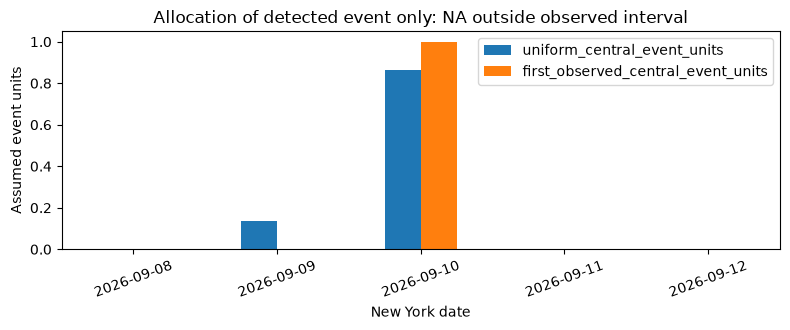

In [9]:
if RESEARCH_READY:
    allocated = allocate_intervals(ledger, as_of=AS_OF, timezone_name=TZ, allocation='uniform')
    endpoint_allocation = allocate_intervals(ledger, as_of=AS_OF, timezone_name=TZ, allocation='first_observed')
    daily_allocations = calendar[['cycle_date', 'coverage_status']].rename(columns={'cycle_date': 'date'}).copy()
    for name, frame in [('uniform_central_event_units', allocated), ('first_observed_central_event_units', endpoint_allocation)]:
        values = frame.loc[frame.method.eq('central_native')].groupby('date').allocated_units.sum()
        daily_allocations[name] = daily_allocations.date.map(values)
    display(daily_allocations)
    display(allocated.loc[allocated.method.eq('central_native'), ['date', 'vin', 'allocated_units', 'allocation_fraction',
        'interval_start', 'interval_end', 'event_available_at', 'evidence_available_at', 'coverage']])
    fig, ax = plt.subplots(figsize=(8, 3.4))
    daily_allocations.set_index('date')[['uniform_central_event_units', 'first_observed_central_event_units']].plot.bar(ax=ax)
    ax.set_title('Allocation of detected event only: NA outside observed interval')
    ax.set_ylabel('Assumed event units'); ax.set_xlabel('New York date'); ax.tick_params(axis='x', rotation=20)
    plt.tight_layout(); plt.show()


## Pending-flag reconciliation and estimate revisions

For matched VINs, the native pending flag can switch in either direction. Adding pending entrants and removing pending departures reconciles the pending stock. These transitions are observations; a cleared flag is not an identified cancellation or completed order. Unknown flags prevent the pending identity from being assessed. Endpoints across the September 10 gap do not recover the missing day's transitions.

The first-Sold contribution below is replayed at its original availability time and compared with the current evidence. Later contrary evidence can withdraw an estimate without erasing the observed Sold event. Repeated Sold observations do not create new units. The provisional/current bridge is an estimate vintage, not a count of actual returns.


In [10]:
if RESEARCH_READY:
    pending_rows = []
    complete_days = days.loc[days.coverage_complete].sort_values('cycle_date')
    for before_day, after_day in zip(complete_days.to_dict('records'), complete_days.to_dict('records')[1:]):
        before = inventory.loc[inventory.cycle_id.eq(before_day['cycle_id'])].set_index(['retailer', 'vin'])
        after = inventory.loc[inventory.cycle_id.eq(after_day['cycle_id'])].set_index(['retailer', 'vin'])
        common = before.index.intersection(after.index)
        added, exited = after.index.difference(before.index), before.index.difference(after.index)
        b, a = before.purchase_pending, after.purchase_pending
        unknown = int(b.isna().sum() + a.isna().sum())
        started = int((b.loc[common].eq(0) & a.loc[common].eq(1)).sum())
        cleared = int((b.loc[common].eq(1) & a.loc[common].eq(0)).sum())
        new_pending, exited_pending = int(a.loc[added].eq(1).sum()), int(b.loc[exited].eq(1).sum())
        pending_rows.append(dict(start_date=before_day['cycle_date'], end_date=after_day['cycle_date'],
            beginning_pending=int(b.eq(1).sum()), matched_pending_entries=started,
            matched_pending_exits=cleared, pending_inventory_additions=new_pending,
            pending_inventory_departures=exited_pending, ending_pending=int(a.eq(1).sum()),
            unknown_flag_observations=unknown,
            residual=(int(a.eq(1).sum()-b.eq(1).sum())-started+cleared-new_pending+exited_pending) if unknown == 0 else pd.NA))
    pending_stock_flow = pd.DataFrame(pending_rows)
    display(pending_stock_flow)
    estimate_revisions = native_estimate_revisions(records, cohorts, as_of=AS_OF,
        cycles=days, observations=inventory)
    display(estimate_revisions)
    research_tables.update(pending_stock_flow=pending_stock_flow, estimate_revisions=estimate_revisions)


,start_date,end_date,beginning_pending,matched_pending_entries,matched_pending_exits,pending_inventory_additions,pending_inventory_departures,ending_pending,unknown_flag_observations,residual
0,2026-09-08,2026-09-09,215,12,22,0,0,205,0,0
1,2026-09-09,2026-09-11,205,75,15,22,60,227,0,0


,event_id,retailer,vin,listing_id,provisional_available_at,provisional_event_units,current_event_units,revised_as_of,unit_revision,reason,contrary_native_at,inventory_reappearance_at,repeat_sold_checks,repeat_hours
0,f8c775195e98303ac5cf,carvana,5YJ3E1EA7NF288274,4567173,2026-09-11 02:23:02.872973+00:00,1.0,1.0,2026-09-12T11:37:13.019826+00:00,0.0,First native Sold event remains eligible,NaT,NaT,0,0.0


## Retained cohort and control follow-up batch

The first saved plan selected nine overdue frozen-cohort members and three seeded
random controls from 379 same-ID VINs present and nonpending at both September 9/11
endpoints. Missing September 10 prevents a continuous-nonpending claim. These
historical results are separate from the next-check preview below.

Compare each VIN's current native fields with its pre-plan baseline. Controls may
have no prior native check; a blank baseline is unknown. Repeated Sold labels do
not add first transitions. The shared loader verifies selected identity, source
hashes and availability before these rows enter the comparison.


In [11]:
if REVIEW_AVAILABLE:
    display(pass_observations[['vin', 'listing_id', 'saleStatus', 'purchaseType', 'inventoryType',
        'observed_status', 'parse_outcome', 'checked_at', 'frozen_cohort_member']])
    # Compare only to evidence frozen before this batch; controls have no native baseline.
    prior = native_visits(records, as_of=review_pass['selection_as_of']).sort_values('checked_at').drop_duplicates(['retailer', 'vin'], keep='last')
    before_columns = ['retailer', 'vin', 'checked_at', 'saleStatus', 'observed_status']
    pass_comparison = pass_observations.merge(prior[before_columns], on=['retailer', 'vin'], how='left', suffixes=('_now', '_before'))
    display(pass_comparison[['vin', 'listing_id', 'saleStatus_before', 'observed_status_before',
        'saleStatus_now', 'observed_status_now', 'checked_at_before', 'checked_at_now']])
    pass_cost = pd.DataFrame([{k: review_pass[k] for k in ['detail_visits', 'usable_native_captures',
        'elapsed_seconds', 'minimum_start_spacing_seconds', 'browser_subrequests', 'inventory_requests_this_continuation',
        'remaining_detail_budget', 'remaining_inventory_window_seconds']}])
    display(pass_cost)
    research_tables.update(prospective_pass=pass_observations, prospective_comparison=pass_comparison, prospective_cost=pass_cost)
else:
    print('First diagnostic pass unavailable at this cutoff; its plan may already be visible below.')


,vin,listing_id,saleStatus,purchaseType,inventoryType,observed_status,parse_outcome,checked_at,frozen_cohort_member
0,5YJ3E1EA0LF611240,4640427,Available,Purchasable,Core,pending,matched,2026-09-11T16:26:36.199000+00:00,True
1,5YJ3E1EA0LF632279,4681095,Available,Purchasable,Core,available,matched,2026-09-11T16:27:07.134000+00:00,True
2,5YJ3E1EA0LF784711,4671091,Available,Reservable,WIP,unknown,matched,2026-09-11T16:27:35.108000+00:00,True
3,5YJ3E1EA2PF544050,4674263,Sold,NotPurchasable,Core,sold_label,matched,2026-09-11T16:28:11.223000+00:00,True
4,5YJ3E1EA0LF793165,4460674,Available,Reservable,WIP,unknown,matched,2026-09-11T16:28:38.278000+00:00,True
5,5YJ3E1EA0PF668477,4722528,Available,Purchasable,Core,available,matched,2026-09-11T16:29:09.338000+00:00,True
6,1C4AJWAG5GL241979,4465259,Sold,NotPurchasable,Core,sold_label,matched,2026-09-11T16:29:36.614000+00:00,True
7,5YJ3E1EA4MF081629,4678187,Available,NotPurchasable,Core,unavailable,matched,2026-09-11T16:29:57.978000+00:00,True
8,WBXHT3C33J5L30739,4436696,Sold,NotPurchasable,Core,sold_label,matched,2026-09-11T16:32:55.357000+00:00,True
9,5YJ3E1EC2LF586200,4709564,Available,Purchasable,Core,available,matched,2026-09-11T16:33:19.439000+00:00,False


,vin,listing_id,saleStatus_before,observed_status_before,saleStatus_now,observed_status_now,checked_at_before,checked_at_now
0,5YJ3E1EA0LF611240,4640427,Available,pending,Available,pending,2026-09-10 00:24:31.909000+00:00,2026-09-11T16:26:36.199000+00:00
1,5YJ3E1EA0LF632279,4681095,Available,pending,Available,available,2026-09-10 00:24:39.371000+00:00,2026-09-11T16:27:07.134000+00:00
2,5YJ3E1EA0LF784711,4671091,Available,unknown,Available,unknown,2026-09-10 00:24:43.163000+00:00,2026-09-11T16:27:35.108000+00:00
3,5YJ3E1EA2PF544050,4674263,Sold,sold_label,Sold,sold_label,2026-09-10 00:25:59.445000+00:00,2026-09-11T16:28:11.223000+00:00
4,5YJ3E1EA0LF793165,4460674,Available,unknown,Available,unknown,2026-09-10 04:10:26.265000+00:00,2026-09-11T16:28:38.278000+00:00
5,5YJ3E1EA0PF668477,4722528,Available,available,Available,available,2026-09-10 04:10:41.306000+00:00,2026-09-11T16:29:09.338000+00:00
6,1C4AJWAG5GL241979,4465259,Sold,sold_label,Sold,sold_label,2026-09-10 00:24:27.812000+00:00,2026-09-11T16:29:36.614000+00:00
7,5YJ3E1EA4MF081629,4678187,Available,unavailable,Available,unavailable,2026-09-10 00:24:35.624000+00:00,2026-09-11T16:29:57.978000+00:00
8,WBXHT3C33J5L30739,4436696,Sold,sold_label,Sold,sold_label,2026-09-10 00:24:46.822000+00:00,2026-09-11T16:32:55.357000+00:00
9,5YJ3E1EC2LF586200,4709564,NaN,NaN,Available,available,NaT,2026-09-11T16:33:19.439000+00:00


,detail_visits,usable_native_captures,elapsed_seconds,minimum_start_spacing_seconds,browser_subrequests,inventory_requests_this_continuation,remaining_detail_budget,remaining_inventory_window_seconds
0,12,12,502.363,21.411,None,0,24,0


## Exit validation: ten ranked exits, separate from the frozen cohort

The retained second pass selected ten of 73 September 9–11 exits by queue rank,
plus two seeded random noncandidate controls from a 590-VIN frame. The exits were
**not randomly selected**. All ten first native checks showed Sold; both controls
showed Available. These counts describe conditional website agreement for the
selected vehicles, not transaction precision or an exit-to-sale conversion rate.

Trace `EXIT_EXAMPLE_VIN = 5YJ3E1EA0MF058297` from its last inventory row to the later
native capture. The first Sold observation does not reveal a sale timestamp. These
ten VINs remain outside the frozen 33 and its single qualifying transition.
The tables retain group, listing identity, check time and source.

The two historical batches total 24 detail visits; browser subrequests are unknown.
The preview below is not a new collection pass. Repeated Sold labels add persistence
evidence, not additional sales.


In [12]:
if not exit_validation.empty:
    exit_validation['group'] = exit_validation.selection_reason.map(lambda reason: 'random noncandidate control' if 'control' in reason else 'recent inventory exit')
    display(exit_validation[['vin', 'listing_id', 'group', 'saleStatus', 'purchaseType', 'observed_status', 'checked_at']])
    exit_status_counts = exit_validation.groupby(['group', 'saleStatus', 'purchaseType']).size().rename('observations').reset_index()
    display(exit_status_counts)
    total_pass_cost = pd.DataFrame([dict(batch=1, **{key: review_pass[key] for key in ['detail_visits', 'elapsed_seconds', 'minimum_start_spacing_seconds']}),
        dict(batch=2, **{key: exit_report[key] for key in ['detail_visits', 'elapsed_seconds', 'minimum_start_spacing_seconds']})])
    display(total_pass_cost)
    # VIN walkthrough: last listing evidence and later native observation, no invented sale timestamp.
    walk_vin = EXIT_EXAMPLE_VIN
    display(inventory.loc[inventory.vin.eq(walk_vin), ['vin', 'listing_id', 'observed_at_utc', 'purchase_pending', 'asking_price_usd', 'source_path']])
    display(exit_validation.loc[exit_validation.vin.eq(walk_vin), ['vin', 'listing_id', 'checked_at', 'saleStatus', 'purchaseType', 'source']])
    research_tables.update(exit_validation=exit_validation, exit_status_counts=exit_status_counts, total_pass_cost=total_pass_cost)
else:
    print('Exit validation results unavailable at this cutoff; a retained plan is not a completed check.')


,vin,listing_id,group,saleStatus,purchaseType,observed_status,checked_at
0,5YJ3E1EA0MF058297,4665793,recent inventory exit,Sold,NotPurchasable,sold_label,2026-09-11T16:36:33.667000+00:00
1,5YJ3E1EA0PF429561,4690183,recent inventory exit,Sold,NotPurchasable,sold_label,2026-09-11T16:36:48.639000+00:00
2,5YJ3E1EA0PF501651,4711088,recent inventory exit,Sold,NotPurchasable,sold_label,2026-09-11T16:37:03.640000+00:00
3,5YJ3E1EA0PF556729,4676574,recent inventory exit,Sold,NotPurchasable,sold_label,2026-09-11T16:37:38.003000+00:00
4,5YJ3E1EA0SF930474,4692403,recent inventory exit,Sold,NotPurchasable,sold_label,2026-09-11T16:37:53.951000+00:00
5,5YJ3E1EA0SF967489,4721394,recent inventory exit,Sold,NotPurchasable,sold_label,2026-09-11T16:38:08.554000+00:00
6,5YJ3E1EA2PF564704,4648265,recent inventory exit,Sold,NotPurchasable,sold_label,2026-09-11T16:38:48.985000+00:00
7,5YJ3E1EA2SF132414,4692833,recent inventory exit,Sold,NotPurchasable,sold_label,2026-09-11T16:39:04.085000+00:00
8,5YJ3E1EA3MF048556,4686725,recent inventory exit,Sold,NotPurchasable,sold_label,2026-09-11T16:39:18.937000+00:00
9,5YJ3E1EA3PF476583,4708929,recent inventory exit,Sold,NotPurchasable,sold_label,2026-09-11T16:39:48.599000+00:00


,group,saleStatus,purchaseType,observations
0,random noncandidate control,Available,Purchasable,1
1,random noncandidate control,Available,Reservable,1
2,recent inventory exit,Sold,NotPurchasable,10


,batch,detail_visits,elapsed_seconds,minimum_start_spacing_seconds
0,1,12,502.363,21.411
1,2,12,225.545,15.004


,vin,listing_id,observed_at_utc,purchase_pending,asking_price_usd,source_path
26,5YJ3E1EA0MF058297,4665793,2026-09-09T01:45:02.291335+00:00,0,23990.0,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
839,5YJ3E1EA0MF058297,4665793,2026-09-09T11:00:25.388489+00:00,0,23990.0,C:\Users\Sean\VscProjects\researchOS\vehicle\d...


,vin,listing_id,checked_at,saleStatus,purchaseType,source
0,5YJ3E1EA0MF058297,4665793,2026-09-11T16:36:33.667000+00:00,Sold,NotPurchasable,c:\Users\Sean\VscProjects\researchOS\vehicle\d...


## Browser detail batches: saved checks and unfinished work

The browser-assisted workflow saves each visit separately. `browser_health` shows
unattempted, unresolved, completed and failed visits at `AS_OF`; a reserved visit
with no saved result remains unresolved even after its collection window expires.
The next-check preview excludes those unresolved reservations until they are
recovered or explicitly closed. A prepared plan is not evidence of a page visit.

`browser_records` contains only completed observations available by the cutoff.
They inform follow-up selection and the optional Clarity comparison below. A check
of an existing frozen-cohort VIN also updates its current native-event estimate;
checks of other validation VINs do not enlarge that cohort. Earlier cutoffs retain
their earlier information, and estimate revisions keep the first contribution visible.
Matched native Sold is a website label, not a delivery date or an economic sale.

Use the [browser batch guide](../docs/browser_detail_batches.md) for the explicit
preview, visit, save and recovery commands. Run All only reads saved evidence;
this notebook does not navigate Chrome or start an unattended collector.


In [13]:
if browser_health.empty:
    print('No browser detail batches available at this cutoff.')
else:
    display(browser_health)
    display(browser_health.groupby(['batch', 'outcome', 'window_expired'], dropna=False)
        .size().rename('planned_targets').reset_index())
if not browser_records.empty:
    display(browser_records[['retailer', 'vin', 'listing_id', 'checked_at', 'available_at',
        'saleStatus', 'purchaseType', 'observed_status', 'parse_outcome', 'source']])


,batch,retailer,vin,listing_id,outcome,started_at,available_at,saleStatus,purchaseType,observed_status,checked_at,source,window_expired
0,20260912_browser_fix_validation,carvana,5YJ3E1EA1MF071110,4659188,matched,2026-09-12T11:32:21.130366+00:00,2026-09-12T11:33:24.942776+00:00,Available,Reservable,unknown,2026-09-12T11:33:11.378000+00:00,c:\Users\Sean\VscProjects\researchOS\vehicle\d...,False
1,20260912_browser_fix_validation,carvana,5YJ3E1EA2LF633062,4652680,matched,2026-09-12T11:33:49.245256+00:00,2026-09-12T11:34:06.029888+00:00,Available,Purchasable,available,2026-09-12T11:33:56.730000+00:00,c:\Users\Sean\VscProjects\researchOS\vehicle\d...,False
2,20260912_browser_fix_validation,carvana,5YJ3E1EA6MF054075,4716143,matched,2026-09-12T11:34:32.183173+00:00,2026-09-12T11:34:49.520903+00:00,Sold,NotPurchasable,sold_label,2026-09-12T11:34:39.662000+00:00,c:\Users\Sean\VscProjects\researchOS\vehicle\d...,False
3,20260912_browser_fix_validation,carvana,5YJ3E1EB7TF171204,4679606,matched,2026-09-12T11:35:13.778336+00:00,2026-09-12T11:35:34.502171+00:00,Sold,NotPurchasable,sold_label,2026-09-12T11:35:24.073000+00:00,c:\Users\Sean\VscProjects\researchOS\vehicle\d...,False
4,20260912_browser_fix_validation,carvana,5YJ3E1EA3MF088216,4683906,matched,2026-09-12T11:36:06.055641+00:00,2026-09-12T11:36:27.399610+00:00,Available,Reservable,unknown,2026-09-12T11:36:16.473000+00:00,c:\Users\Sean\VscProjects\researchOS\vehicle\d...,False
5,20260912_browser_fix_validation,carvana,5YJ3E1EAXPF419068,4693117,matched,2026-09-12T11:36:54.247529+00:00,2026-09-12T11:37:13.019826+00:00,Available,Purchasable,pending,2026-09-12T11:37:02.477000+00:00,c:\Users\Sean\VscProjects\researchOS\vehicle\d...,False
6,20260912T034900Z,carvana,5YJ3E1EA1MF071110,4659188,unattempted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
7,20260912T034900Z,carvana,5YJ3E1EA2PF428587,4665345,unattempted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
8,20260912T034900Z,carvana,5YJ3E1EA4LF804149,4633716,unattempted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
9,20260912T034900Z,carvana,5YJ3E1EB5NF274902,4579967,unattempted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


,batch,outcome,window_expired,planned_targets
0,20260912T034900Z,unattempted,True,6
1,20260912_browser_fix_validation,matched,False,6


,retailer,vin,listing_id,checked_at,available_at,saleStatus,purchaseType,observed_status,parse_outcome,source
0,carvana,5YJ3E1EA1MF071110,4659188,2026-09-12T11:33:11.378000+00:00,2026-09-12T11:33:24.942776+00:00,Available,Reservable,unknown,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
1,carvana,5YJ3E1EA2LF633062,4652680,2026-09-12T11:33:56.730000+00:00,2026-09-12T11:34:06.029888+00:00,Available,Purchasable,available,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
2,carvana,5YJ3E1EA6MF054075,4716143,2026-09-12T11:34:39.662000+00:00,2026-09-12T11:34:49.520903+00:00,Sold,NotPurchasable,sold_label,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
3,carvana,5YJ3E1EB7TF171204,4679606,2026-09-12T11:35:24.073000+00:00,2026-09-12T11:35:34.502171+00:00,Sold,NotPurchasable,sold_label,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
4,carvana,5YJ3E1EA3MF088216,4683906,2026-09-12T11:36:16.473000+00:00,2026-09-12T11:36:27.399610+00:00,Available,Reservable,unknown,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
5,carvana,5YJ3E1EAXPF419068,4693117,2026-09-12T11:37:02.477000+00:00,2026-09-12T11:37:13.019826+00:00,Available,Purchasable,pending,matched,c:\Users\Sean\VscProjects\researchOS\vehicle\d...


## Next checks: outstanding episodes and sampling frames

An exit stays visible through later complete or incomplete sweeps until its study
follow-up is complete. `exit_episodes` preserves each disappearance and return;
`followup_selection` shows one current target per retailer/VIN. Reappearance or a new
listing identity requires a fresh matched check of that target. A failed visit
never supplies native evidence or completes a follow-up.

For a selected validation vehicle, check after 24 hours, then at seven days from
its first matched check of the current target. A matched check at or after that
seven-day milestone completes this bounded follow-up; it does not confirm a sale.
A late first repeat can meet that minimum without a separate 24-hour visit; the
missed intermediate observation remains unobserved. Frozen-cohort vehicles keep their separate recurring 24-hour reminder.

Priority identity/status conflicts come first. Remaining slots cover due persistence
checks, seeded random new exits and seeded random noncandidate controls. Groups are
disjoint; each VIN can appear at most once. The table retains eligible frames,
selected counts, seed and reasons. Only actual random draws receive `k/N` inclusion
probabilities. Changing the seed changes an offline preview, not a saved plan.

Keep the existing 12-visit cap and at least 15 seconds between visit starts if a
future pass is separately authorized. A few controls cannot establish a reliable
missed-event rate, and no sample is scaled to company sales.


In [14]:
if RESEARCH_READY:
    exit_episodes = inventory_exit_episodes(days, inventory, as_of=AS_OF)
    followup_selection = inventory_followup_queue(days, inventory, queue_records, cohorts,
        as_of=AS_OF, selection_plans=selection_plans, browser_health=browser_health, batch_limit=BATCH_LIMIT,
        control_count=CONTROL_COUNT, seed=SELECTION_SEED)
    next_checks = followup_selection.loc[followup_selection.selected_for_check].copy()
    due_rechecks = followup_selection.loc[followup_selection.frozen_cohort_member & followup_selection.check_due]
    print('Offline preview at:', AS_OF, '| seed:', SELECTION_SEED)
    print('Frozen cohort VINs retained:', int(followup_selection.frozen_cohort_member.sum()))
    display(next_checks[['retailer', 'vin', 'frozen_cohort_member', 'selection_group',
        'episode_listing_id', 'followup_listing_id', 'first_disappearance_at',
        'last_usable_native_at', 'next_check_at', 'followup_outstanding',
        'completion_reason', 'selection_probability', 'selection_reason', 'followup_url']])
    followup_sampling = followup_selection[['selection_group', 'frame_size', 'frame_selected',
        'selection_seed', 'eligibility_rule']].drop_duplicates().sort_values('selection_group')
    display(followup_sampling)
    display(followup_selection.groupby(['selection_reason', 'selected_for_check'], dropna=False)
        .size().rename('VINs').reset_index())
    print('Exit episodes retain disappearance and later reappearance evidence:')
    display(exit_episodes[['retailer', 'vin', 'listing_id', 'first_disappearance_at',
        'reappeared_at', 'reappeared_listing_id', 'exit_episode_id']])
    research_tables.update(followup_selection=followup_selection, due_rechecks=due_rechecks,
        exit_episodes=exit_episodes, followup_sampling=followup_sampling)


Offline preview at: 2026-09-12T11:37:13.019826+00:00 | seed: carvana-vendor-review-20260911
Frozen cohort VINs retained: 33


,retailer,vin,frozen_cohort_member,selection_group,episode_listing_id,followup_listing_id,first_disappearance_at,last_usable_native_at,next_check_at,followup_outstanding,completion_reason,selection_probability,selection_reason,followup_url
0,carvana,5YJ3E1EA2PF428587,True,persistence,NaN,4665345,NaN,2026-09-11 02:17:07.050000+00:00,2026-09-12 11:37:13.019826+00:00,True,Frozen cohort continues on its 24-hour reminder,NaN,cohort continuity,https://www.carvana.com/vehicle/4665345
1,carvana,5YJ3E1EA3NF372799,False,persistence,NaN,4677227,NaN,NaT,2026-09-12 11:37:13.019826+00:00,True,Needs a matched native baseline on this target,NaN,noncandidate inventory control,https://www.carvana.com/vehicle/4677227
2,carvana,5YJ3E1EA4LF804149,False,persistence,4633716,4633716,2026-09-11T10:55:10.719183+00:00,NaT,2026-09-12 11:37:13.019826+00:00,True,Needs a matched native baseline on this target,NaN,outstanding inventory exit episode,https://www.carvana.com/vehicle/4633716
3,carvana,5YJ3E1EA4MF072462,True,persistence,NaN,4728005,NaN,2026-09-11 02:17:40.259000+00:00,2026-09-12 11:37:13.019826+00:00,True,Frozen cohort continues on its 24-hour reminder,NaN,cohort continuity,https://www.carvana.com/vehicle/4728005
4,carvana,5YJ3E1EA5NF322616,True,persistence,NaN,4713082,NaN,2026-09-11 02:18:41.172000+00:00,2026-09-12 11:37:13.019826+00:00,True,Frozen cohort continues on its 24-hour reminder,NaN,cohort continuity,https://www.carvana.com/vehicle/4713082
59,carvana,5YJ3E1EA4LF785926,False,new_exit,4577877,4577877,2026-09-11T10:55:10.719183+00:00,NaT,2026-09-12 11:37:13.019826+00:00,True,Needs a matched native baseline on this target,0.089286,outstanding inventory exit episode,https://www.carvana.com/vehicle/4577877
67,carvana,5YJ3E1EA6PF568870,False,new_exit,4691547,4691547,2026-09-11T10:55:10.719183+00:00,NaT,2026-09-12 11:37:13.019826+00:00,True,Needs a matched native baseline on this target,0.089286,outstanding inventory exit episode,https://www.carvana.com/vehicle/4691547
76,carvana,5YJ3E1EA8SF909954,False,new_exit,4732712,4732712,2026-09-11T10:55:10.719183+00:00,NaT,2026-09-12 11:37:13.019826+00:00,True,Needs a matched native baseline on this target,0.089286,outstanding inventory exit episode,https://www.carvana.com/vehicle/4732712
85,carvana,5YJ3E1EB2MF855501,False,new_exit,4691083,4691083,2026-09-11T10:55:10.719183+00:00,NaT,2026-09-12 11:37:13.019826+00:00,True,Needs a matched native baseline on this target,0.089286,outstanding inventory exit episode,https://www.carvana.com/vehicle/4691083
108,carvana,5YJ3E1EC6PF609435,False,new_exit,4692976,4692976,2026-09-11T10:55:10.719183+00:00,NaT,2026-09-12 11:37:13.019826+00:00,True,Needs a matched native baseline on this target,0.089286,outstanding inventory exit episode,https://www.carvana.com/vehicle/4692976


,selection_group,frame_size,frame_selected,selection_seed,eligibility_rule
199,control,584,2,carvana-vendor-review-20260911,Known evidence; 24h since any VIN visit; study...
112,event_change,87,0,carvana-vendor-review-20260911,Known evidence; 24h since any VIN visit; study...
56,new_exit,56,5,carvana-vendor-review-20260911,Known evidence; 24h since any VIN visit; study...
0,persistence,26,5,carvana-vendor-review-20260911,Known evidence; 24h since any VIN visit; study...


,selection_reason,selected_for_check,VINs
0,cohort continuity,False,21
1,cohort continuity,True,3
2,known native Sold; research follow-up,False,2
3,noncandidate inventory control,False,590
4,noncandidate inventory control,True,3
5,outstanding inventory exit episode,False,54
6,outstanding inventory exit episode,True,6
7,outstanding inventory exit episode; known nati...,False,14
8,pending started or pending cleared,False,90


Exit episodes retain disappearance and later reappearance evidence:


,retailer,vin,listing_id,first_disappearance_at,reappeared_at,reappeared_listing_id,exit_episode_id
0,carvana,5YJ3E1EAXPF590130,4632932,2026-09-09T11:01:07.356095+00:00,NaT,None,52d556b08089d7542790de0e17c29cacf4fbdcb01132d5...
1,carvana,5YJ3E1EA0MF058297,4665793,2026-09-11T10:55:10.719183+00:00,NaT,None,c9885c4610ef70503773ce554a7cba8a92f4fc3eb20e44...
2,carvana,5YJ3E1EA0PF429561,4690183,2026-09-11T10:55:10.719183+00:00,NaT,None,29d3e8a38c0c4eeea909005e11e570d8b13c8284546d11...
3,carvana,5YJ3E1EA0PF501651,4711088,2026-09-11T10:55:10.719183+00:00,NaT,None,4ba6bdf349fe063230f81c5ad5ade0fda145d659f38791...
4,carvana,5YJ3E1EA0PF556729,4676574,2026-09-11T10:55:10.719183+00:00,NaT,None,f2099295e9f48802f7c8622cd623349b20647433c607cc...
...,...,...,...,...,...,...,...
69,carvana,5YJ3E1EC6NF210635,4672156,2026-09-11T10:55:10.719183+00:00,NaT,None,c10bd6354c16bd61fbe130558b40c7e9cb7230a61b3a95...
70,carvana,5YJ3E1EC6PF609435,4692976,2026-09-11T10:55:10.719183+00:00,NaT,None,4df4dc5762f0042db6a8e612672f73b4b5baccc317b95a...
71,carvana,5YJ3E1ET3SF943687,4643933,2026-09-11T10:55:10.719183+00:00,NaT,None,8b3764884a3072c50397a145b29054d2b74df2e0aac8f1...
72,carvana,5YJ3E1ET3TF136975,4651834,2026-09-11T10:55:10.719183+00:00,NaT,None,345cff2c53a02971bdf043ed7de80c473264e227982971...


## Limits and reproducibility

The central result uses first native Sold transitions in the frozen cohort.
Persistent absence needs consecutive complete dates; missing September 10 breaks
that continuity. An unavailable absence estimate is not zero. The independent
transaction count and national conversion rate remain unknown. Notebook 30 shows
which assumptions and quarterly evidence would be needed before extrapolation.

The optional studies below retain the old evidence and calculations. They do not
change frozen membership. Run All only reads local files. To reproduce tables
explicitly, choose a **new temporary destination**:

```powershell
.\.venv\Scripts\python.exe -B vehicle/scripts/export_sales_proxy.py --as-of 2026-09-11T16:41:25.820875+00:00 --destination "$env:TEMP\carvana-review-CHOOSE-A-NEW-NAME"
```

The exporter rejects an existing destination and records input/code/output hashes.
[Research log](../docs/daily_sales_research_20260911.md) |
[Vendor sources](../docs/carvana_daily_sales_external_research.md).


## Optional A. Earlier native persistence holdout

Usable native pairs require matched identity and exact Available/Sold values. Compare them separately from interpreted purchase status. The holdout freezes the evidence at September 10 04:12:06 UTC, then examines genuinely later checks excluded at that cutoff. It tests later website status, not transaction accuracy. A pending flag is not a calibrated prediction.

In [15]:
if RESEARCH_READY:
    valid = visits.loc[visits.parse_outcome.eq('matched') & visits.saleStatus.isin(['Available', 'Sold'])].sort_values('checked_at').copy()
    valid['previous_native'] = valid.groupby(['retailer', 'vin']).saleStatus.shift()
    valid['previous_check'] = valid.groupby(['retailer', 'vin']).checked_at.shift()
    valid['pair_hours'] = (valid.checked_at - valid.previous_check).dt.total_seconds() / 3600
    native_pairs = valid.dropna(subset=['previous_native']).groupby(['previous_native', 'saleStatus']).agg(
        pairs=('vin', 'size'), min_hours=('pair_hours', 'min'), median_hours=('pair_hours', 'median'), max_hours=('pair_hours', 'max')).reset_index()
    display(native_pairs)
    HOLDOUT = pd.Timestamp('2026-09-10T04:12:06Z')
    baseline_visits = native_visits(records, as_of=min(pd.Timestamp(AS_OF), HOLDOUT))
    baseline = baseline_visits.loc[baseline_visits.parse_outcome.eq('matched') & baseline_visits.saleStatus.isin(['Available', 'Sold'])].sort_values('checked_at').drop_duplicates(['retailer', 'vin'], keep='last')
    baseline = baseline.loc[baseline.saleStatus.eq('Available')]
    first_native = baseline_visits.loc[baseline_visits.parse_outcome.eq('matched') & baseline_visits.saleStatus.isin(['Available', 'Sold'])].sort_values('checked_at').drop_duplicates(['retailer', 'vin'], keep='first')
    prospective = panel.loc[panel.role.eq('prospective_inventory'), ['retailer', 'vin']].merge(first_native.loc[first_native.saleStatus.eq('Available'), ['retailer', 'vin']])
    baseline = baseline.merge(prospective, on=['retailer', 'vin'])
    later = valid.loc[valid.checked_at.gt(HOLDOUT)].sort_values('checked_at').drop_duplicates(['retailer', 'vin'], keep='last')
    holdout = baseline.merge(later, on=['retailer', 'vin'], suffixes=('_baseline', '_later'))
    holdout_table = holdout.groupby(['observed_status_baseline', 'saleStatus_later', 'observed_status_later']).size().rename('VINs').reset_index()
    display(holdout_table)
    print('Later usable native outcomes:', len(holdout), '| transaction outcomes: unavailable')
    print('Naive pending=Sold would label', int(holdout.observed_status_baseline.eq('pending').sum()),
          'of these VINs; later native Sold labels:', int(holdout.saleStatus_later.eq('Sold').sum()))


,previous_native,saleStatus,pairs,min_hours,median_hours,max_hours
0,Available,Available,42,0.389413,25.909260,40.089543
1,Available,Sold,1,25.881039,25.881039,25.881039
2,Sold,Sold,7,0.394798,12.696354,40.135704


,observed_status_baseline,saleStatus_later,observed_status_later,VINs
0,available,Available,available,2
1,available,Available,pending,2
2,pending,Available,available,2
3,pending,Available,pending,14
4,pending,Sold,sold_label,1
5,unavailable,Available,unavailable,1
6,unknown,Available,unknown,7


Later usable native outcomes: 29 | transaction outcomes: unavailable
Naive pending=Sold would label 17 of these VINs; later native Sold labels: 1


## Optional B. Historical inventory experiment

Two September 8 intraday experiments used exactly the same seven query definitions, ZIP, sort and location-filter settings. They are useful chronological evidence, but are **not extra daily registered observations**. We independently verify their retained query reports before combining them with the three registered sweeps. Do not count intraday checks as absent calendar days.

Those legacy captures do not retain a separate source-availability clock. Their role here is a retrospective reappearance experiment, first verified for this study at September 11 12:48:13 UTC; they are excluded from earlier research vintages. This is not a point-in-time performance backtest. Later checks are held out chronologically from the disappearance prediction.

In [16]:
if RESEARCH_READY:
    LEGACY_VERIFIED_AT = pd.Timestamp('2026-09-11T12:48:13Z')
    snapshot_rows, snapshot_info = [], []
    if pd.Timestamp(AS_OF) >= LEGACY_VERIFIED_AT:
        for label in ['20260908_mvp1000_verified', '20260908_history_trial/repeat']:
            parts, runs = [], []
            for query in SETTINGS['queries']:
                path = ROOT / 'data/experiments' / label / query['query_id'] / 'run_report.json'
                run, captures, rows = read_query_evidence(path)
                context = json.loads(run['context_json'])
                assert run['query_complete'] and context['filters'] == query['filters']
                assert context['zip_code'] == query['zip_code'] and context['location_filter'] == query['location_filter']
                assert context['sort'] == 'MostPopular'
                part = rows.merge(captures[['capture_id', 'source_path']], on='capture_id', validate='many_to_one')
                parts.append(part); runs.append(run); input_paths.add(path)
                input_paths.update(Path(p) for p in captures.source_path)
            frame = pd.concat(parts, ignore_index=True)
            assert not frame.duplicated(['retailer', 'vin']).any()
            snapshot_rows.append(frame.assign(snapshot=label))
            snapshot_info.append(dict(snapshot=label, start=frame.observed_at_utc.min(), end=frame.observed_at_utc.max(),
                vins=frame.vin.nunique(), research_available_at=LEGACY_VERIFIED_AT.isoformat(), legacy_availability_unknown=True))
    for day in days.itertuples():
        frame = inventory.loc[inventory.cycle_id.eq(day.cycle_id)]
        if not day.coverage_complete: continue
        snapshot_rows.append(frame.assign(snapshot=day.cycle_date))
        snapshot_info.append(dict(snapshot=day.cycle_date, start=day.window_start, end=day.window_end,
            vins=frame.vin.nunique(), research_available_at=day.available_at, legacy_availability_unknown=False))
    snapshots = pd.DataFrame(snapshot_info).sort_values('start')
    all_observations = pd.concat(snapshot_rows, ignore_index=True)
    departure_events, returned_events, previous, open_departures = [], [], {}, {}
    for snapshot in snapshots.itertuples():
        current = {(r.retailer, r.vin): r for r in all_observations.loc[all_observations.snapshot.eq(snapshot.snapshot)].itertuples()}
        for key in sorted(previous.keys() - current.keys()):
            old = previous[key]
            event = dict(retailer=key[0], vin=key[1], listing_id=old.listing_id,
                last_present_at=old.observed_at_utc, first_absent_by=snapshot.end,
                first_absent_snapshot=snapshot.snapshot, previous_pending=old.purchase_pending,
                last_present_source=old.source_path)
            departure_events.append(event); open_departures[key] = event
        for key in sorted(current.keys() & open_departures.keys()):
            old_event = open_departures.pop(key)
            returned_events.append(dict(old_event, returned_at=current[key].observed_at_utc,
                returned_listing_id=current[key].listing_id, returned_source=current[key].source_path))
        previous = current
    departures = pd.DataFrame(departure_events)
    reappearances = pd.DataFrame(returned_events)
    disappearance_holdout = reappearance_summary(
        departures, reappearances, latest_snapshot=snapshots.iloc[-1].snapshot)
    display(snapshots)
    display(disappearance_holdout)
    display(reappearances)


,snapshot,start,end,vins,research_available_at,legacy_availability_unknown
0,20260908_mvp1000_verified,2026-09-08T11:32:58.875154+00:00,2026-09-08T11:34:37.788042+00:00,694,2026-09-11T12:48:13+00:00,True
1,20260908_history_trial/repeat,2026-09-08T12:14:13.197536+00:00,2026-09-08T12:15:51.874512+00:00,693,2026-09-11T12:48:13+00:00,True
2,2026-09-08,2026-09-09T01:44:11.074146+00:00,2026-09-09T01:45:40.704618+00:00,674,2026-09-09T01:45:40.724750+00:00,False
3,2026-09-09,2026-09-09T10:59:31.570451+00:00,2026-09-09T11:01:07.356095+00:00,681,2026-09-09T11:01:07.378901+00:00,False
4,2026-09-11,2026-09-11T10:53:30.283953+00:00,2026-09-11T10:55:10.719183+00:00,706,2026-09-11T10:55:10.763717+00:00,False


,earlier_departure_episodes,later_reappeared_episodes,earlier_departed_vins,later_reappeared_vins,latest_departures_right_censored,observed_return_fraction,episode_return_fraction,interpretation
0,54,9,54,9,73,0.166667,0.166667,Separate episode and unique retailer/VIN fract...


,retailer,vin,listing_id,last_present_at,first_absent_by,first_absent_snapshot,previous_pending,last_present_source,returned_at,returned_listing_id,returned_source
0,carvana,5YJ3E1EA0PF663232,4687487,2026-09-08T12:14:39.990499+00:00,2026-09-09T01:45:40.704618+00:00,2026-09-08,1,C:\Users\Sean\VscProjects\researchOS\vehicle\d...,2026-09-09T10:59:40.329009+00:00,4687487,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
1,carvana,5YJ3E1EC5NF169902,4688113,2026-09-08T12:15:03.950313+00:00,2026-09-09T01:45:40.704618+00:00,2026-09-08,1,C:\Users\Sean\VscProjects\researchOS\vehicle\d...,2026-09-09T11:00:01.617494+00:00,4688113,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
2,carvana,5YJ3E1EA2PF561706,4666298,2026-09-08T12:14:39.990499+00:00,2026-09-09T01:45:40.704618+00:00,2026-09-08,1,C:\Users\Sean\VscProjects\researchOS\vehicle\d...,2026-09-11T10:53:55.760776+00:00,4666298,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
3,carvana,5YJ3E1EA4PF558936,4685803,2026-09-08T12:14:33.991636+00:00,2026-09-09T01:45:40.704618+00:00,2026-09-08,1,C:\Users\Sean\VscProjects\researchOS\vehicle\d...,2026-09-11T10:53:37.689250+00:00,4685803,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
4,carvana,5YJ3E1EA7LF599345,4670303,2026-09-08T12:15:40.062544+00:00,2026-09-09T01:45:40.704618+00:00,2026-09-08,1,C:\Users\Sean\VscProjects\researchOS\vehicle\d...,2026-09-11T10:54:58.828965+00:00,4670303,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
5,carvana,5YJ3E1EB1NF267087,4694751,2026-09-08T12:14:54.893009+00:00,2026-09-09T01:45:40.704618+00:00,2026-09-08,0,C:\Users\Sean\VscProjects\researchOS\vehicle\d...,2026-09-11T10:54:19.713557+00:00,4694751,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
6,carvana,5YJ3E1EB4MF067979,4621777,2026-09-08T12:15:18.967741+00:00,2026-09-09T01:45:40.704618+00:00,2026-09-08,0,C:\Users\Sean\VscProjects\researchOS\vehicle\d...,2026-09-11T10:54:28.702577+00:00,4621777,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
7,carvana,5YJ3E1EB7MF948045,4485697,2026-09-08T12:15:09.999550+00:00,2026-09-09T01:45:40.704618+00:00,2026-09-08,0,C:\Users\Sean\VscProjects\researchOS\vehicle\d...,2026-09-11T10:54:28.702577+00:00,4485697,C:\Users\Sean\VscProjects\researchOS\vehicle\d...
8,carvana,5YJ3E1EB8MF053034,4654263,2026-09-08T12:15:09.999550+00:00,2026-09-09T01:45:40.704618+00:00,2026-09-08,0,C:\Users\Sean\VscProjects\researchOS\vehicle\d...,2026-09-11T10:54:28.702577+00:00,4654263,C:\Users\Sean\VscProjects\researchOS\vehicle\d...


## Optional C. Frozen sampling and price audit

The extension sampled 18 of 204 pending and 8 of 474 nonpending eligible vehicles (seed and selection records remain in the frozen cohort). A model-based projection requires outcomes over a common follow-up window. Its known design weights are `204/18 = 11.333` and `474/8 = 59.25`, but current checks are irregular, some vehicles were already Sold at baseline, and there are no independent outcomes. Multiplying this one transition by a design weight would project a **status event** under additional assumptions, not validated retail sales; we do not publish that number as a sales estimate.

Four chosen model families are a convenience frame, not a probability sample of Carvana. Models/years outside the frame have zero inclusion probability; national design weights cannot be estimated. The new four-model trial failed before retention. Existing single-query trials can inform cost, but are not a contemporaneous broad census.

Retain native inventory types below. Numeric bulk codes are not silently mapped to partner ownership. Carvana's SEC retail-unit denominator **includes Marketplace partner units**, so excluding every partner would not match the official target. Neither this population nor this indicator can be scaled to the reported Q2 2026 **197,325 units (2,168.4/day arithmetic average)**. [Official definition and totals](https://www.sec.gov/Archives/edgar/data/1690820/000169082026000055/cvna-20260630.htm).

The matched-price calculation is mean(current asking price − prior asking price) on the same VINs with both prices. A change in overall mean can come from additions/departures. No price here is a transaction price.

In [17]:
if RESEARCH_READY:
    extension = next((c for c in cohorts if 'selection' in c), None)
    if extension:
        source_cycle = extension['selection']['source']['cycle_id']
        source_inventory = inventory.loc[inventory.cycle_id.eq(source_cycle)]
        prior_inventory = inventory.loc[pd.to_datetime(inventory.observed_at_utc, utc=True).le(pd.Timestamp(extension['selected_at']))]
        sampled, counts = select_extension(source_inventory, prior_inventory, cohorts[0], seed=extension['selection']['seed'])
        assert set(sampled.loc[sampled.selected].vin) == {v['vin'] for v in extension['vehicles']}
        assert counts.to_dict('records') == extension['selection']['counts']
        sampling = counts.rename(columns={'pending_group': 'stratum', 'eligible': 'eligible_frame'})
    else:
        sampling = pd.DataFrame(columns=['stratum', 'selected', 'eligible_frame'])
    sampling['inclusion_probability'] = sampling.selected / sampling.eligible_frame
    sampling['design_weight_if_common_outcomes_available'] = sampling.eligible_frame / sampling.selected
    sampling['selected_share'] = sampling.selected / sampling.selected.sum()
    sampling['frame_share'] = sampling.eligible_frame / sampling.eligible_frame.sum()
    display(sampling)
    native_inventory_types = inventory.groupby(['inventory_type', 'on_demand'], dropna=False).size().rename('observation_rows').reset_index()
    native_page_types = visits.groupby(['inventoryType', 'saleStatus'], dropna=False).size().rename('physical_checks').reset_index()
    display(native_inventory_types); display(native_page_types)
    display(flows[['interval_start', 'interval_end', 'matched_vins', 'matched_price_pairs', 'repriced_vins',
        'matched_mean_price_change_usd', 'beginning_mean_ask_usd', 'ending_mean_ask_usd']])


,stratum,requested,eligible_frame,selected,inclusion_probability,design_weight_if_common_outcomes_available,selected_share,frame_share
0,true,18,204,18,0.088235,11.333333,0.692308,0.300885
1,false,8,474,8,0.016878,59.250000,0.307692,0.699115


,inventory_type,on_demand,observation_rows
0,1,0,1293
1,2,1,768


,inventoryType,saleStatus,physical_checks
0,Core,Available,54
1,Core,Sold,11
2,WIP,Available,18
3,NaN,NaN,1


,interval_start,interval_end,matched_vins,matched_price_pairs,repriced_vins,matched_mean_price_change_usd,beginning_mean_ask_usd,ending_mean_ask_usd
0,2026-09-09T01:44:11.074146+00:00,2026-09-09T11:01:07.356095+00:00,673,673,0,0.000000,28219.376855,28292.202643
1,2026-09-09T10:59:31.570451+00:00,2026-09-11T10:55:10.719183+00:00,608,608,51,-37.828947,28292.202643,28371.303116


## Optional D. Cutoff and duplicate-evidence checks

The tables above test real retained observations. The test suite separately uses explicitly synthetic observations for duplicate checks, later corrections, missing dates, scope changes, relisting, conflicting identities, failed captures, later availability, simultaneous contradictory labels and daylight-saving allocation.

Below we exclude the first Sold evidence at the second before its local import. A source observed earlier but imported later must not count at the earlier cutoff. Repeating the same physical check also must not add an event.

In [18]:
if RESEARCH_READY:
    if not native_events.empty:
        before_import = (pd.Timestamp(native_events.event_available_at.min()) - pd.Timedelta(seconds=1)).isoformat()
        earlier, _ = native_transition_events(records, cohorts, as_of=before_import, cycles=days, observations=inventory)
        duplicated, _ = native_transition_events(pd.concat([records, records]), cohorts, as_of=AS_OF, cycles=days, observations=inventory)
        cutoff_checks = pd.DataFrame([dict(check='One second before first-Sold import', event_count=len(earlier)),
                                     dict(check='Current complete retained evidence', event_count=len(native_events)),
                                     dict(check='Same physical evidence provided twice', event_count=len(duplicated))])
        assert set(native_events.event_id).isdisjoint(earlier.event_id) and len(duplicated) == len(native_events)
        display(cutoff_checks)
    else: cutoff_checks = pd.DataFrame()


,check,event_count
0,One second before first-Sold import,0
1,Current complete retained evidence,1
2,Same physical evidence provided twice,1


## Optional E. Vendor workbook investigation

JXCE discloses automated public-web collection plus proprietary modeling. Indra/Clarity publishes distinct listings, orders, pending, sales and delivery metrics, but the reviewed pages do not disclose reproducible event rules. The workbook is a dated aggregate output, not VIN-level transaction evidence. This compact table separates disclosures from hypotheses; exact source links, cell addresses, dated forecasts and competing tests are in the [external research note](../docs/carvana_daily_sales_external_research.md).

| Metric | Explicit evidence | Plausible calculation from Carvana observations | Unknown / distinguishing test |
|---|---|---|---|
| Daily sales | Vendor estimates; workbook C | First non-Sold-to-Sold transition, exits, or delayed absence with revisions | Reconcile same VIN episodes across all methods and later reappearance; quarterly fit cannot identify daily accuracy |
| Orders | Separate vendor/workbook O series | Entries into pending, perhaps repeated orders | Count unique pending-entry episodes; compare orders with pending entries and gross clears |
| Pending inventory | Workbook BK stock; native pending flag exists | Count current pending VINs within a fixed frame | Exact stock boundary and unknown flags; reconcile matched transitions and inventory entrants/exits |
| New listings | Workbook S series | Newly observed listing IDs or VIN episodes | Relists vs first-ever VIN; compare both identity definitions |
| Reappearances | Repeated public VIN/listing observations | Return after a complete-scope absence | Same/new listing ID does not identify return vs canceled order; retain separate episodes |
| Processing time | JXCE advertises order processing; WIP/Reservable states also observed | Pending-to-Sold could measure order time; WIP-to-purchasable measures preparation | Start/end rules and censoring unknown; follow separate predeclared pending and WIP cohorts |
| Delivery estimate | Vendor metric; public delivery fields and ZIP-dependent logic | Aggregate quoted delivery days for a fixed ZIP/eligible set | Capture same VIN at two ZIPs contemporaneously; quote is not actual delivery |
| Prices / Sold Price | Advertised prices; workbook labels alone do not define realization | Last observed asking price among inferred sales | Match VIN-level price to capture and transaction record; transaction price currently unverified |
| Quarterly run rate | Workbook I/J formula directly observable | Current QTD / prior QTD × prior full quarter | Prior-year series normalization and vintage; compare against a flat daily alternative |

Dated JXCE forecasts and dated Indra samples exist before the relevant earnings releases, but mutable webpage dates do not establish an immutable old forecast vintage. Neither their quarterly errors nor vendor agreement validates individual daily sales. Registration/ownership histories offer different evidence, with lag, corrected titles, seller attribution and permitted-use questions still unresolved. Carvana's target includes Marketplace partner retail units and is net of returns.


In [19]:
vendor_path = ROOT / 'data/experiments/vendor_method_audit/20260911T162442Z/audit.json'
pass_path = REVIEW / 'pass.json'
if REVIEW_AVAILABLE:
    audit = json.loads(vendor_path.read_text(encoding='utf-8'))
    workbook_source = REVIEW / 'vendor_workbook.xlsx'
    assert hashlib.sha256(workbook_source.read_bytes()).hexdigest() == audit['sha256_before'] == audit['sha256_after']
    vendor_manifest = vendor_path.parent / 'public_source_manifest.json'
    for entry in json.loads(vendor_manifest.read_text(encoding='utf-8')):
        source = ROOT / entry['source']
        assert pd.Timestamp(entry['checked_at']) <= pd.Timestamp(AS_OF)
        assert hashlib.sha256(source.read_bytes()).hexdigest() == entry['sha256']
        input_paths.add(source)
    input_paths.update([vendor_path, vendor_manifest, workbook_source, pass_path, REVIEW / 'visible_check_plan.json'])
    vendor_daily = pd.DataFrame(audit['daily_rows'])
    populated = vendor_daily.loc[vendor_daily.current_year_sales.notna()].copy()
    qtd_current = populated.current_year_sales.sum()
    qtd_prior = populated.prior_year_sales.sum()
    full_prior = vendor_daily.prior_year_sales.sum()
    workbook_run_rate = pd.DataFrame([dict(source_date=populated.date.iloc[-1],
        current_qtd=qtd_current, prior_qtd=qtd_prior, prior_quarter=full_prior,
        seasonal_run_rate=qtd_current / qtd_prior * full_prior,
        flat_calendar_run_rate=qtd_current / len(populated) * len(vendor_daily),
        formula_cell='Sheet1!J41', formula=audit['summary_cells']['J41'])])
    display(workbook_run_rate)
    # These are hypotheses about common timing/population, not cancellation formulas.
    populated['implied_inventory_exits'] = populated.inventory.shift() + populated.new_listings - populated.inventory
    populated['exits_minus_sales'] = populated.implied_inventory_exits - populated.current_year_sales
    populated['implied_pending_clears'] = populated.pending.shift() + populated.orders - populated.pending
    vendor_flows = populated[['source_row', 'date', 'inventory', 'new_listings', 'current_year_sales',
        'implied_inventory_exits', 'exits_minus_sales', 'pending', 'orders', 'implied_pending_clears']]
    display(vendor_flows.loc[vendor_flows.source_row.isin([3, 6, 7, 8])])
    print('39 computable intervals, unexplained net exit/sales residual:', populated.exits_minus_sales.sum())
    factor = audit['prior_year_normalization']['factor']
    normalized_prior = vendor_daily[['date', 'prior_year_sales']].copy()
    normalized_prior['candidate_integer_before_scaling'] = (normalized_prior.prior_year_sales / factor).round()
    normalized_prior['reconstruction_error'] = normalized_prior.prior_year_sales - normalized_prior.candidate_integer_before_scaling * factor
    print('All 92 fractional daily values fit integer counts × 155941/158863; max error:', normalized_prior.reconstruction_error.abs().max())
    display(pd.DataFrame([audit['population_checks']]))
    print('111 is the smallest compatible tested model-year denominator, not a verified sample size. 74,347 is incompatible.')
    print("Sold-year 50/50 mix is incompatible with the same day's odd 2,159 sales if both use the full unit population.")
    research_tables.update(vendor_daily=vendor_daily, vendor_stock_flow=vendor_flows,
        workbook_run_rate=workbook_run_rate, normalized_prior=normalized_prior)
else:
    print('Continuation audit/pass not yet available at this cutoff; excluded from exported review tables.')


,source_date,current_qtd,prior_qtd,prior_quarter,seasonal_run_rate,flat_calendar_run_rate,formula_cell,formula
0,2026-08-09 00:00:00,91901.0,65581.149859,155941.0,218525.199267,211372.3,Sheet1!J41,=(I41+1)*SUM(D$2:D$93)


,source_row,date,inventory,new_listings,current_year_sales,implied_inventory_exits,exits_minus_sales,pending,orders,implied_pending_clears
1,3,2026-07-02 00:00:00,75792.0,3941.0,2376.0,2496.0,120.0,16334.0,3291.0,3339.0
4,6,2026-07-05 00:00:00,72229.0,135.0,1119.0,1424.0,305.0,15194.0,2121.0,1331.0
5,7,2026-07-06 00:00:00,72229.0,0.0,2152.0,0.0,-2152.0,15194.0,2891.0,2891.0
6,8,2026-07-07 00:00:00,72043.0,4609.0,2182.0,4795.0,2613.0,15758.0,3501.0,2937.0


39 computable intervals, unexplained net exit/sales residual: 12171.0
All 92 fractional daily values fit integer counts × 155941/158863; max error: 4.547473508864641e-13


,AK2_smallest_compatible_denominator_tested,denominator_search_max,AK2_categories_incompatible_with_BL2,AK2_category_count,BL2,CE2_equal_halves_incompatible_with_C2,meaning
0,111,500,16,16,74347,True,different population or erroneous output; smal...


111 is the smallest compatible tested model-year denominator, not a verified sample size. 74,347 is incompatible.
Sold-year 50/50 mix is incompatible with the same day's odd 2,159 sales if both use the full unit population.


## Optional F. Retained collector comparison

Use the existing public search POST for inventory and asking prices. Ordinary detail pages complement it with exact native status, rather than acting as a fallback after an access block. The retained search response matched all 21 rendered cards; JSON-LD matched only 20 despite also containing 21 rows. Counting pages or trusting displayed totals alone misses stale identities, promotions and mutable ordering.

The latest retained seven-query sweep used 35 explicit POSTs and 100.435 seconds between capture endpoints for 706 VINs. The older 500-request broad trial admitted 10,019 VINs but only 9,107 belonged to completed queries. These are measured outcomes for selected populations, not a national census. The 80,576 older displayed total implies a conditional lower bound of 3,358 requests at 24 rows/request and 2.80 hours at three-second spacing, before partition overhead or failures.

The optional price-history fields below are now retained when present. Twenty missing values do not mean no repricing. Marketplace/store indicators in this sample do not establish seller attribution. Public delivery estimates are context-dependent quotes; paired full-population delivery coverage across ZIPs remains unmeasured. Twenty retained, page-referenced JavaScript assets were hash-checked during this continuation; their ZIP-dependent delivery/pricing branches are corroboration, not actual fulfillment evidence.

Historical collection context: The earlier four-model trial made one explicit POST, received HTTP 200, then failed to retain its response: zero admitted rows. Its fixed inventory window expired at **12:57:34 UTC**; 119 nominal unused requests cannot restart that window. This continuation reused retained inventory and completed two separate 12-page native detail batches. The measured pass, field comparison, workbook reconstruction and remaining limits appear below. No operating database or frozen cohort membership changed.



In [20]:
if REVIEW_AVAILABLE:
    collector_path = REVIEW / 'collector_evidence.json'
    collector = json.loads(collector_path.read_text(encoding='utf-8'))
    input_paths.add(collector_path)
    for source in collector['source_files']:
        source_path = ROOT / source['path']
        assert hashlib.sha256(source_path.read_bytes()).hexdigest() == source['sha256']
        input_paths.add(source_path)
    method_measurements = pd.DataFrame(collector['methods'])
    display(method_measurements.reindex(columns=['method', 'run', 'usable_unique_vins', 'complete_query_vins',
        'duplicate_admitted_vin_memberships', 'complete_queries', 'explicit_requests', 'elapsed_seconds', 'elapsed_definition']))
    public_field_coverage = pd.DataFrame.from_dict(collector['paired_public_search_page']['field_coverage'], orient='index').rename_axis('field').reset_index()
    display(public_field_coverage)
    # Read actual retained fields, rather than treating a prose report as the source row.
    raw_path = ROOT / collector['paired_public_search_page']['sources'][0]
    raw = json.loads(raw_path.read_text(encoding='utf-8'))
    price_rows = pd.json_normalize(raw['inventory']['vehicles'])
    retained_price_history = price_rows.reindex(columns=['vin', 'vehicleId', 'price.total', 'previousPrice', 'priceUpdateDate'])
    display(retained_price_history.loc[retained_price_history.previousPrice.notna()])
    research_tables.update(collector_methods=method_measurements, public_field_coverage=public_field_coverage,
        retained_price_history=retained_price_history)


,method,run,usable_unique_vins,complete_query_vins,duplicate_admitted_vin_memberships,complete_queries,explicit_requests,elapsed_seconds,elapsed_definition
0,public_search_POST,mvp,1006.0,694.0,0.0,7.0,47.0,138.937639,full invocation duration
1,public_search_POST,broader_sample,10019.0,9107.0,0.0,158.0,500.0,1500.754134,full invocation duration
2,public_search_POST,intraday_repeat,693.0,693.0,0.0,7.0,34.0,99.788286,full invocation duration
3,public_search_POST,parent_zip_audit,69.0,69.0,138.0,4.0,10.0,27.855332,full invocation duration
4,public_search_POST,daily_2026_09_08,674.0,674.0,0.0,7.0,31.0,90.724483,full invocation duration
5,public_search_POST,daily_2026_09_09,681.0,681.0,0.0,7.0,33.0,96.833702,full invocation duration
6,public_search_POST,daily_2026_09_11,706.0,706.0,NaN,7.0,35.0,100.435230,first response capture to last response captur...
7,ordinary_public_page_detail_native_RSC,retained_33_VIN_cohort_at_12_48_13Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,field,present,nonnull,missing_or_null
0,vin,21,21,0
1,vehicleId,21,21,0
2,saleStatus,0,0,21
3,vehiclePurchaseType,21,21,0
4,isPurchasePending,21,21,0
5,vehicleInventoryType,21,21,0
6,previousPrice,1,1,20
7,priceUpdateDate,1,1,20
8,stores,21,21,0
9,storeKey,21,21,0


,vin,vehicleId,price.total,previousPrice,priceUpdateDate
5,5YJ3E1ET7SF002520,4635054,49590.0,49990.0,2026-09-02T15:02:19.188Z


## Optional G. What does Clarity actually disclose, and can we test it?

**Review these five cells in order:** `clarity-method-settings`, `clarity-orders`,
`clarity-exit-rules`, `clarity-transport`, `clarity-workbooks`. Run All stays offline.
The notebook defaults to the September 12 browser validation cutoff.
`AS_OF_OVERRIDE` still controls every section; earlier cutoffs hide this later study.

Clarity's [public Carvana factsheet](https://zwexremjcszwnbaldhkh.supabase.co/storage/v1/object/public/faq-sheets/Clarity_CVNA_Coverage_FAQ.pdf),
linked from its [product page](https://www.clarity-markets.com/data/CVNA), identifies
Carvana.com as the source. It defines orders as entry into Purchase Pending for
the first time within the preceding week. Pending includes brief reservations
and vehicles awaiting fulfillment. The factsheet does **not** disclose the sale
trigger, endpoint, collection frequency, timezone or exact weekly reset rule.
Its claimed order conversion and historical accuracy are not our calibration.

A plausible workflow is a VIN/listing inventory history, pending-entry events,
detail status checks and reappearance/return adjustments. This is an inference,
not recovered vendor code. The following rule comparison is retrospective;
its later native checks measure website corroboration in a selected subset.
Only the six-target HTTP plan was frozen before this task's new page request.
Neither experiment validates delivered sales or national representativeness.

In [21]:
from vehicle_tracker.clarity_experiment import pending_entry_experiment, exit_rule_experiment, load_detail_probe

CLARITY_STUDY = ROOT / 'data/experiments/clarity_method/20260912T032143Z/study.json'
assert hashlib.sha256(CLARITY_STUDY.read_bytes()).hexdigest() == '537519568b4c3b967d25f7feb6fc80f9762b6e46d43e2af890202f2615a5195a'
clarity_study = json.loads(CLARITY_STUDY.read_text(encoding='utf-8'))
CLARITY_AVAILABLE = pd.Timestamp(AS_OF) >= pd.Timestamp(clarity_study['available_at'])
clarity_orders = clarity_order_coverage = clarity_exit_rules = clarity_rule_summary = pd.DataFrame()
clarity_transport = clarity_workbook_versions = clarity_workbook_changes = clarity_stock_flow = pd.DataFrame()
if CLARITY_AVAILABLE:
    # Bind reports, original workbooks, source PDF, frozen plan and exact trial code.
    for relative, expected_hash in clarity_study['files'].items():
        source = ROOT / relative
        assert hashlib.sha256(source.read_bytes()).hexdigest() == expected_hash, relative
        input_paths.add(source)
    input_paths.add(CLARITY_STUDY)
    clarity_sources = {key: ROOT / relative for key, relative in clarity_study['sources'].items()}
    clarity_probe, clarity_native = load_detail_probe(clarity_sources['probe'], clarity_sources['plan'], as_of=AS_OF)
    clarity_records = pd.concat([queue_records, clarity_native], ignore_index=True) if not clarity_native.empty else queue_records
    print('Clarity study available:', clarity_study['available_at'], '| evidence cutoff:', AS_OF)
    print('Separate research records; operating inventory and frozen-cohort estimates are unchanged.')
else:
    print('Clarity study was not retained at this cutoff; its tables are unavailable.')

Clarity study available: 2026-09-12T03:29:50.837558+00:00 | evidence cutoff: 2026-09-12T11:37:13.019826+00:00
Separate research records; operating inventory and frozen-cohort estimates are unchanged.


### 1. Reconstruct a rolling-week order proxy

Our explicit interpretation: a false-to-true pending change after seven complete
prior calendar dates, with no observed entry during the preceding six dates.
Every observed entry resets the cooldown, including suppressed repeats.
Initially pending vehicles, relistings and missing before/after coverage cannot
establish a new eligible order. Daily snapshots can miss short reservations,
so even a fully observed daily proxy is not equivalent to the vendor's orders.

In [22]:
if CLARITY_AVAILABLE:
    clarity_orders = pending_entry_experiment(days, inventory, as_of=AS_OF)
    clarity_order_coverage = (clarity_orders.groupby(
        ['entry_observed', 'order_proxy_eligible', 'reason'], dropna=False)
        .size().rename('observations').reset_index())
    display(clarity_order_coverage)
    display(clarity_orders.loc[clarity_orders.entry_observed].head(12))
    if not clarity_orders.order_proxy_eligible.any():
        print('No qualifying observed entries at this cutoff; inspect coverage and exclusions. This is not a company orders count.')

,entry_observed,order_proxy_eligible,reason,observations
0,False,False,first/unknown pending baseline,237
1,True,False,incomplete interval or changed listing,75
2,True,False,missing complete prior week,12


,retailer,vin,listing_id,cycle_date,checked_at,available_at,entry_observed,continuous_pair,complete_prior_week,previous_entry_date,repeat_within_week,order_proxy_eligible,reason
215,carvana,5YJ3E1EA2RF745157,4691207,2026-09-09,2026-09-09T10:59:34.346362+00:00,2026-09-09T11:01:07.378901+00:00,True,True,False,NaN,False,False,missing complete prior week
216,carvana,5YJ3E1EA3PF476583,4708929,2026-09-09,2026-09-09T10:59:58.335963+00:00,2026-09-09T11:01:07.378901+00:00,True,True,False,NaN,False,False,missing complete prior week
217,carvana,5YJ3E1EA5NF290668,4654791,2026-09-09,2026-09-09T11:00:13.406079+00:00,2026-09-09T11:01:07.378901+00:00,True,True,False,NaN,False,False,missing complete prior week
218,carvana,5YJ3E1EA6PF623513,4652008,2026-09-09,2026-09-09T10:59:55.365510+00:00,2026-09-09T11:01:07.378901+00:00,True,True,False,NaN,False,False,missing complete prior week
219,carvana,5YJ3E1EA7MF047569,4708633,2026-09-09,2026-09-09T11:00:37.376028+00:00,2026-09-09T11:01:07.378901+00:00,True,True,False,NaN,False,False,missing complete prior week
220,carvana,5YJ3E1EA8NF327826,4684557,2026-09-09,2026-09-09T11:00:13.406079+00:00,2026-09-09T11:01:07.378901+00:00,True,True,False,NaN,False,False,missing complete prior week
221,carvana,5YJ3E1EB1PF471892,4574237,2026-09-09,2026-09-09T10:59:52.501065+00:00,2026-09-09T11:01:07.378901+00:00,True,True,False,NaN,False,False,missing complete prior week
222,carvana,5YJ3E1EB2NF135830,4709594,2026-09-09,2026-09-09T11:00:16.491287+00:00,2026-09-09T11:01:07.378901+00:00,True,True,False,NaN,False,False,missing complete prior week
223,carvana,5YJ3E1EB5MF056280,4686780,2026-09-09,2026-09-09T11:00:40.526415+00:00,2026-09-09T11:01:07.378901+00:00,True,True,False,NaN,False,False,missing complete prior week
224,carvana,5YJ3E1EC1LF641266,4724279,2026-09-09,2026-09-09T11:00:55.370587+00:00,2026-09-09T11:01:07.378901+00:00,True,True,False,NaN,False,False,missing complete prior week


No qualifying observed entries at this cutoff; inspect coverage and exclusions. This is not a company orders count.


### 2. Compare four exit rules on the same episodes

Compare all inventory exits, pending-before-exit, and complete three-/seven-day
absences. Each rule has its own decision time. Exclude native Sold already known
then; later checks must match retailer, VIN and listing and precede an observed
reappearance. A later Sold belonging to a new exit cannot validate an old exit.

`eligible_for_followup` includes unresolved episodes; `checked_episodes` is the
smaller evaluated subset. No observed Sold is not an independently verified
non-sale. Three/seven-day counts of zero selected episodes mean no matured
rule candidates at this cutoff, not zero company sales. Reappearances are
inventory events and need not be customer returns.

In [23]:
if CLARITY_AVAILABLE:
    clarity_exit_rules = exit_rule_experiment(days, inventory, clarity_records, as_of=AS_OF)
    summary_rows = clarity_exit_rules.assign(
        checked_episode=lambda d: d.evaluable & d.matched_later_checks.gt(0),
        sold_corroborated=lambda d: d.evaluable & d.later_sold_seen.eq(True).fillna(False),
        unchecked_episode=lambda d: d.evaluable & d.matched_later_checks.eq(0),
        selected_reappearance=lambda d: d.selected & d.inventory_reappeared)
    clarity_rule_summary = summary_rows.groupby('rule', sort=False).agg(
        exit_episodes=('exit_episode_id', 'size'), selected=('selected', 'sum'),
        sold_already_known=('sold_known_at_decision', 'sum'),
        eligible_for_followup=('evaluable', 'sum'), checked_episodes=('checked_episode', 'sum'),
        later_native_sold=('sold_corroborated', 'sum'), unchecked=('unchecked_episode', 'sum'),
        selected_reappearances=('selected_reappearance', 'sum')).reset_index()
    display(clarity_rule_summary)
    display(clarity_exit_rules.loc[clarity_exit_rules.evaluable & clarity_exit_rules.matched_later_checks.gt(0),
        ['rule', 'vin', 'listing_id', 'decision_at', 'matched_later_checks',
         'first_later_native', 'latest_later_native', 'followup_censored_at']].head(12))
    print('Selected historical subset; neither transaction precision/recall nor company sales is estimable here.')

,rule,exit_episodes,selected,sold_already_known,eligible_for_followup,checked_episodes,later_native_sold,unchecked,selected_reappearances
0,all_exits,74,74,2,72,14,12,58,0
1,pending_before_exit,74,60,2,58,11,10,47,0
2,absence_3d,74,0,0,0,0,0,0,0
3,absence_7d,74,0,0,0,0,0,0,0


,rule,vin,listing_id,decision_at,matched_later_checks,first_later_native,latest_later_native,followup_censored_at
0,all_exits,5YJ3E1EAXPF590130,4632932,2026-09-09 11:01:07.378901+00:00,4,Available,Available,2026-09-12 11:37:13.019826+00:00
4,all_exits,5YJ3E1EA0MF058297,4665793,2026-09-11 10:55:10.763717+00:00,1,Sold,Sold,2026-09-12 11:37:13.019826+00:00
8,all_exits,5YJ3E1EA0PF429561,4690183,2026-09-11 10:55:10.763717+00:00,1,Sold,Sold,2026-09-12 11:37:13.019826+00:00
9,pending_before_exit,5YJ3E1EA0PF429561,4690183,2026-09-11 10:55:10.763717+00:00,1,Sold,Sold,2026-09-12 11:37:13.019826+00:00
12,all_exits,5YJ3E1EA0PF501651,4711088,2026-09-11 10:55:10.763717+00:00,1,Sold,Sold,2026-09-12 11:37:13.019826+00:00
13,pending_before_exit,5YJ3E1EA0PF501651,4711088,2026-09-11 10:55:10.763717+00:00,1,Sold,Sold,2026-09-12 11:37:13.019826+00:00
16,all_exits,5YJ3E1EA0PF556729,4676574,2026-09-11 10:55:10.763717+00:00,1,Sold,Sold,2026-09-12 11:37:13.019826+00:00
20,all_exits,5YJ3E1EA0PF668477,4722528,2026-09-11 10:55:10.763717+00:00,1,Available,Available,2026-09-12 11:37:13.019826+00:00
21,pending_before_exit,5YJ3E1EA0PF668477,4722528,2026-09-11 10:55:10.763717+00:00,1,Available,Available,2026-09-12 11:37:13.019826+00:00
24,all_exits,5YJ3E1EA0SF930474,4692403,2026-09-11 10:55:10.763717+00:00,1,Sold,Sold,2026-09-12 11:37:13.019826+00:00


Selected historical subset; neither transaction precision/recall nor company sales is estimable here.


### 3. Can anonymous HTML replace the current browser capture?

The new CLI reads a frozen plan, previews by default, and performs at most six
anonymous public detail GETs with 15-second spacing and a 25-second timeout.
It stops on the first HTTP, access, identity or parsing failure. The parser only
extracts selected native vehicle fields from public HTML/RSC; it executes no
JavaScript. This trial hit HTTP 403 on request one: **zero valid native captures**.
The other five targets are unattempted, not failed status checks. No retry or
automatic browser fallback was made. Failed HTTP access says nothing about Sold.
Successful extraction has synthetic parser tests but remains unproven live.

In [24]:
if CLARITY_AVAILABLE:
    attempted = {row['expected']['listing_id']: row for row in clarity_probe['attempts']}
    transport_rows = []
    for target in clarity_probe['plan']['pages']:
        attempt = attempted.get(target['listing_id'], {})
        transport_rows.append(dict(vin=target['vin'], listing_id=target['listing_id'],
            selection_group=target['selection_group'], prior_native_status=target['prior_native_status'],
            attempted=bool(attempt), outcome=attempt.get('outcome', 'unattempted'),
            http_status=attempt.get('http_status'), checked_at=attempt.get('checked_at'),
            error=attempt.get('error'), source=str(clarity_sources['probe'])))
    clarity_transport = pd.DataFrame(transport_rows)
    display(clarity_transport)
    print('Run status:', clarity_probe['status'], '| requests:', clarity_probe['requests'],
          '| valid native captures:', len(clarity_native), '| stop:', clarity_probe.get('stop_reason'))

,vin,listing_id,selection_group,prior_native_status,attempted,outcome,http_status,checked_at,error,source
0,5YJ3E1EA1MF071110,4659188,persistence,Available,True,unresolved,403.0,2026-09-12T03:26:16.123333+00:00,HTTP 403; no retry or fallback,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
1,5YJ3E1EA2PF428587,4665345,persistence,Available,False,unattempted,NaN,NaN,NaN,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
2,5YJ3E1EB4NF134453,4622991,new_exit,NaN,False,unattempted,NaN,NaN,NaN,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
3,5YJ3E1EB9NF335670,4290464,new_exit,NaN,False,unattempted,NaN,NaN,NaN,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
4,5YJ3E1EA8PF473730,4721570,control,NaN,False,unattempted,NaN,NaN,NaN,c:\Users\Sean\VscProjects\researchOS\vehicle\d...
5,5YJ3E1EB9NF240073,4709889,control,NaN,False,unattempted,NaN,NaN,NaN,c:\Users\Sean\VscProjects\researchOS\vehicle\d...


Run status: stopped | requests: 1 | valid native captures: 0 | stop: HTTP 403; no retry or fallback


### 4. What do the workbook versions constrain?

File hashes identify unique vintages; download names and modification times
do not establish publication dates. Blank free-sample sales remain missing.
The comparison separates changed values/formulas, cached values, and formatting.
An unchanged pair of overlapping reports cannot prove that all historical
estimates are immutable. No workbook contains VIN-level transaction labels.

The inventory residual below assumes listings are additions to the same
population over the same daily interval. A residual challenges that combined
assumption and a simple inventory-drop-equals-sales rule; it is not a count
of cancellations, returns or vendor errors.

In [25]:
if CLARITY_AVAILABLE:
    versions_audit = json.loads(clarity_sources['workbooks'].read_text(encoding='utf-8'))
    clarity_workbook_versions = pd.DataFrame([dict(
        sha256=v['sha256'], filenames='; '.join(v['input_names']),
        sales_dates=v['sales_dates'], last_sales_date=v['last_sales_date'],
        blank_sales_dates=v['blank_sales_dates'], source_date_rows=v['source_date_rows'])
        for v in versions_audit['versions']])
    clarity_workbook_changes = pd.DataFrame([dict(
        before=v['before_sha256'], after=v['after_sha256'],
        unchanged_existing_values_formulas=v['unchanged_existing_source_count'],
        **{key: len(v[key]) for key in ['added', 'removed', 'changed_source', 'changed_cache', 'format_only']})
        for v in versions_audit['comparisons']])
    latest_version = max(versions_audit['versions'], key=lambda v: v['sales_dates'])
    clarity_stock_flow = pd.DataFrame(latest_version['stock_flow'])
    display(clarity_workbook_versions)
    display(clarity_workbook_changes)
    display(clarity_stock_flow.tail(5))
    print('Unexplained stock-flow residual under a common population/window assumption; not economic sales.')

,sha256,filenames,sales_dates,last_sales_date,blank_sales_dates,source_date_rows
0,12fc1e1b2bb302efeb69add986ddd3f555b9a08a156649...,CVNA_Q2_2025_Summary_Free.xlsx,1,2025-04-01,90,91
1,93fc82eda262c9f00ca42e46f406a7fa015e16fa16e89e...,CVNA_Q2_2025_Summary(2).xlsx; CVNA_Q2_2025_Sum...,32,2025-05-02,59,91
2,b868e2d3b164d7269e61400701dad2693322d5209082dd...,CVNA_Q2_2025_Summary(5).xlsx,37,2025-05-07,54,91


,before,after,unchanged_existing_values_formulas,added,removed,changed_source,changed_cache,format_only
0,12fc1e1b2bb302efeb69add986ddd3f555b9a08a156649...,93fc82eda262c9f00ca42e46f406a7fa015e16fa16e89e...,1240,2021,0,2,0,0
1,12fc1e1b2bb302efeb69add986ddd3f555b9a08a156649...,b868e2d3b164d7269e61400701dad2693322d5209082dd...,1240,2376,0,2,0,25
2,93fc82eda262c9f00ca42e46f406a7fa015e16fa16e89e...,b868e2d3b164d7269e61400701dad2693322d5209082dd...,3263,355,0,0,0,78


,date,implied_exits,reported_sales,unexplained_residual,source_cells
31,2025-05-03,1998,1707,291,"[Sheet1!BJ33, Sheet1!Q34, Sheet1!BJ34, Sheet1!..."
32,2025-05-04,1429,1002,427,"[Sheet1!BJ34, Sheet1!Q35, Sheet1!BJ35, Sheet1!..."
33,2025-05-05,2016,1751,265,"[Sheet1!BJ35, Sheet1!Q36, Sheet1!BJ36, Sheet1!..."
34,2025-05-06,1413,1319,94,"[Sheet1!BJ36, Sheet1!Q37, Sheet1!BJ37, Sheet1!..."
35,2025-05-07,8326,1560,6766,"[Sheet1!BJ37, Sheet1!Q38, Sheet1!BJ38, Sheet1!..."


Unexplained stock-flow residual under a common population/window assumption; not economic sales.


### Historical proposal: 14 collection days plus seven follow-up days

The earlier Clarity investigation proposed a small-scope test with 14 consecutive
complete inventory dates followed by seven more days of follow-up. It is retained
as historical study context, **not the current operating instruction**. Its
[original report](../docs/clarity_method_experiment.md) preserves the evidence,
assumptions and proposed rules; those rules are not retuned to later outcomes here.

The current prepared workflow is the [seven-date, fixed 101-query operating plan](../data/experiments/mvp_completion_20260912/scale_acceptance_20260912/proposed_seven_date_validation.md).
Use Notebook 20 for that population and Notebook 24 for an explicitly selected
status experiment. The seven daily cycles remain a separate live authorization.

Seven inventory dates do not mature every seven-day absence event: an exit near
the end still needs later complete observations. Keep unobserved follow-up missing,
separate priority cases from probability samples and preserve first endpoints.
Neither a completed operating test nor vendor workbook agreement supplies
transaction labels, known delivery dates or a national sales multiplier.


In [26]:
# One registry after all calculations; export_sales_proxy.py reads it explicitly.
if RESEARCH_READY:
    research_tables.update(inventory_flows=flows, native_history=visits, native_events=native_events,
        cohort_panel=panel, estimates=output_table, scenario_totals=scenario_totals, daily_allocations=daily_allocations,
        event_allocations=allocated, absence_comparison=absence_comparison, native_pairs=native_pairs,
        native_holdout=holdout_table, inventory_snapshots=snapshots, disappearance_holdout=disappearance_holdout,
        reappearances=reappearances, source_trace=trace_table, sampling=sampling,
        cutoff_checks=cutoff_checks, collection_costs=collection_costs)


# Optional Clarity study tables use the same evidence cutoff as the main workflow.
research_tables.update(clarity_orders=clarity_orders, clarity_order_coverage=clarity_order_coverage,
    clarity_exit_rules=clarity_exit_rules, clarity_rule_summary=clarity_rule_summary,
    clarity_transport=clarity_transport, clarity_workbook_versions=clarity_workbook_versions,
    clarity_workbook_changes=clarity_workbook_changes, clarity_stock_flow=clarity_stock_flow)

# Each saved browser visit and unfinished reservation is reviewable offline.
research_tables.update(browser_health=browser_health, browser_records=browser_records)
